In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from src.models import SIRM, SIRT, SIRV
from helps import *

In [2]:
temp = read_json("./parameters.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]
rect_coords_M = [mus["pol"][0], mus["h"][0], mus["pol"][2]-mus["pol"][0], mus["h"][2]-mus["h"][0]]
rect_coords_T = [taus["pol"][0], taus["h"][0], taus["pol"][2]-taus["pol"][0], taus["h"][2]-taus["h"][0]]
rect_coords_V = [xis["pol"][0], xis["h"][0], xis["pol"][2]-xis["pol"][0], xis["h"][2]-xis["h"][0]]

In [3]:
# visualization parameters
colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 10, 20],
        'xlim': [0, 1],
        'ylim': [0, 20]
    }

# PS = 20

In [4]:
def calculate_min_max(RM_1_L, pol_range, homophilic_tendency):
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))

    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))

    return max_pol, max_homophily, min_pol, min_homophily

In [18]:
xzz

NameError: name 'xzz' is not defined

In [7]:
betas = np.linspace(0.1, 1, 20)
PS = 5
i = 0

min_POL3 = np.zeros(len(betas))
max_POL3 = np.zeros(len(betas))

min_HOM3 = np.zeros(len(betas))
max_HOM3 = np.zeros(len(betas))

NP = 100
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 50, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    max_POL3[i], max_HOM3[i], min_POL3[i], min_HOM3[i] = calculate_min_max(RM_1_L, pol_range, homophilic_tendency)
    i += 1


0.1
0.1473684210526316
0.19473684210526315
0.24210526315789474
0.2894736842105263
0.33684210526315794
0.38421052631578945
0.43157894736842106
0.4789473684210527
0.5263157894736842
0.5736842105263158
0.6210526315789474
0.6684210526315789
0.7157894736842105
0.7631578947368421
0.8105263157894737
0.8578947368421053
0.9052631578947369
0.9526315789473684
1.0


In [ ]:
betas = np.linspace(0.1, 1, 20)
PS = 31
i = 0

min_POL2 = np.zeros(len(betas))
max_POL2 = np.zeros(len(betas))

min_HOM2 = np.zeros(len(betas))
max_HOM2 = np.zeros(len(betas))
ALL_RES = []
NP = 100
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 50, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    ALL_RES.append(RM_1_L)
    max_POL2[i], max_HOM2[i], min_POL2[i], min_HOM2[i] = calculate_min_max(RM_1_L, pol_range, homophilic_tendency)
    i += 1


0.1
0.1473684210526316
0.19473684210526315
0.24210526315789474
0.2894736842105263
0.33684210526315794
0.38421052631578945
0.43157894736842106
0.4789473684210527
0.5263157894736842
0.5736842105263158
0.6210526315789474
0.6684210526315789
0.7157894736842105
0.7631578947368421
0.8105263157894737
0.8578947368421053
0.9052631578947369
0.9526315789473684
1.0


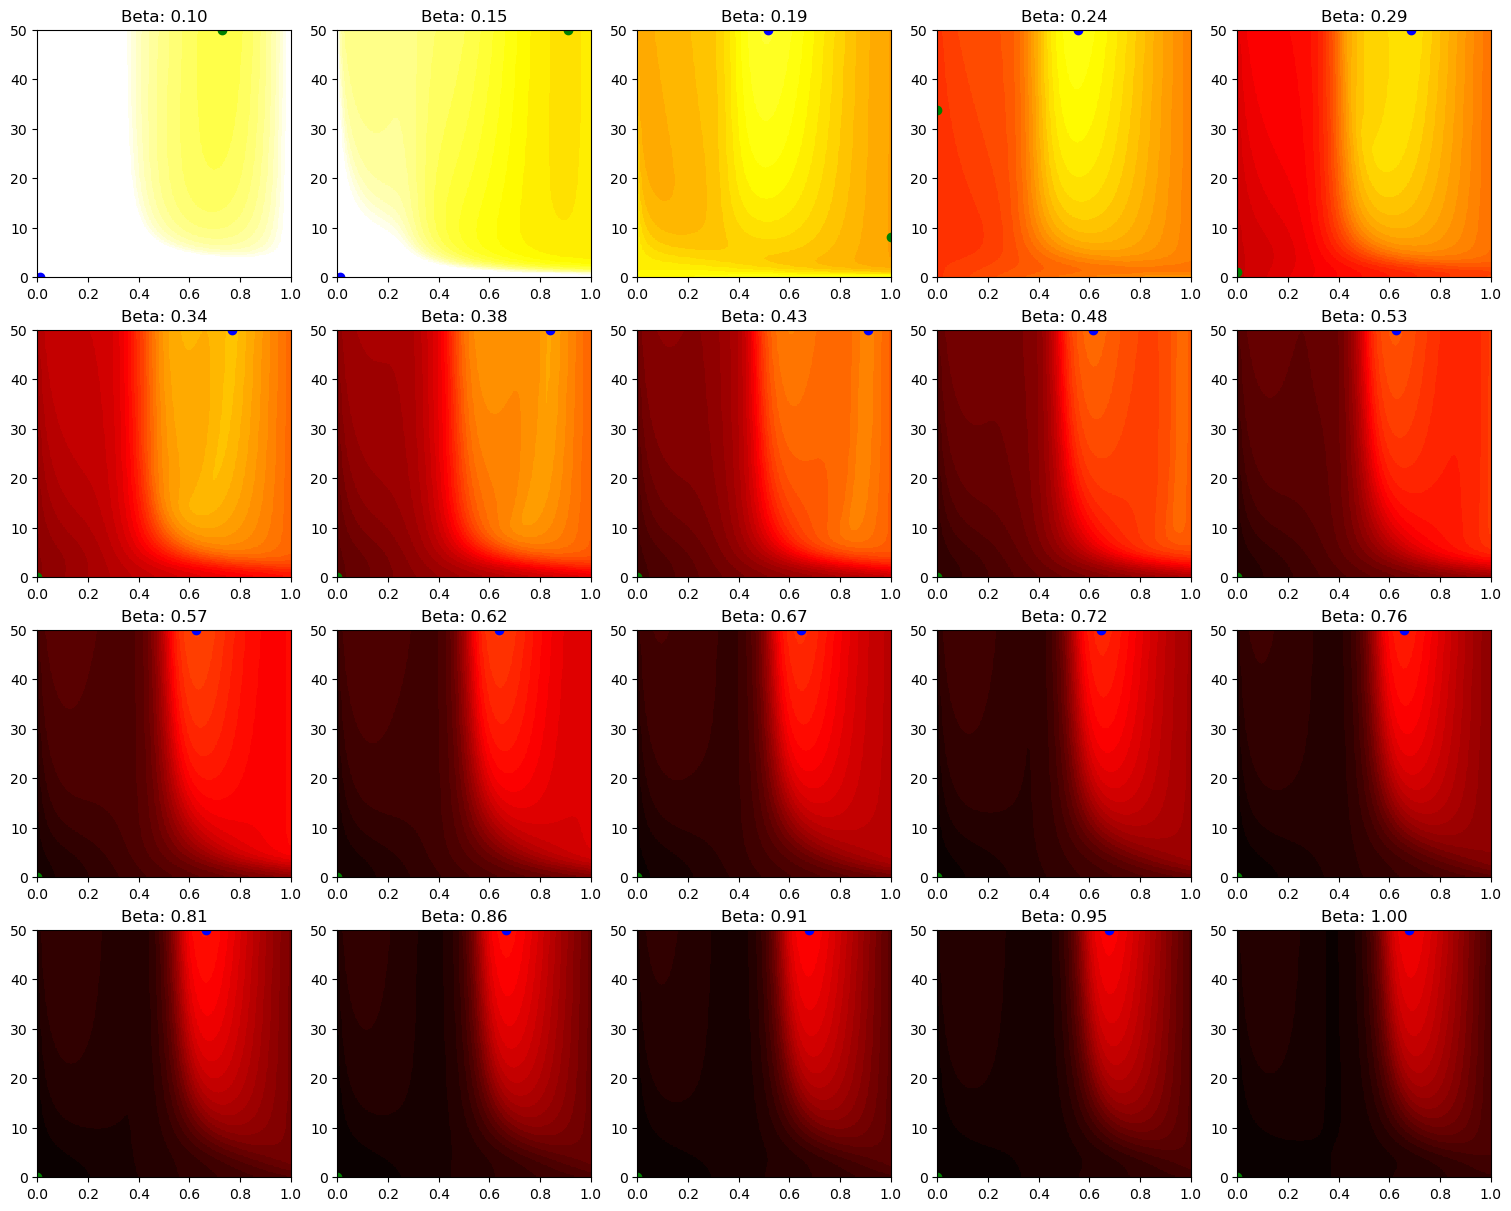

In [24]:
fig, axs = plt.subplots(4,5, figsize=(15,12), constrained_layout=True)
coords = [(i // 5, i % 5) for i in range(20)]
for i in range(len(betas)):
    row, col = coords[i]
    ax = axs[row, col]
    RM_1_L = ALL_RES[i]
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)

    im = ax.imshow(TI, origin='lower', extent=(0,1,0,50), aspect='auto', cmap=my_map, vmin = 0, vmax = 1)
    ax.set_title(f"Beta: {betas[i]:.2f}")
    ax.scatter([min_POL2[i]], [min_HOM2[i]], color='blue')
    ax.scatter([max_POL2[i]], [max_HOM2[i]], color='green')

In [54]:
betas = np.linspace(0.1, 3, 20)
PS = 11
i = 0

min_POL2 = np.zeros(len(betas))
max_POL2 = np.zeros(len(betas))

min_HOM2 = np.zeros(len(betas))
max_HOM2 = np.zeros(len(betas))
ALL_RES = []
NP = 100
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 50, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    ALL_RES.append(RM_1_L)
    max_POL2[i], max_HOM2[i], min_POL2[i], min_HOM2[i] = calculate_min_max(RM_1_L, pol_range, homophilic_tendency)
    i += 1


0.1
0.25263157894736843
0.4052631578947369
0.5578947368421052
0.7105263157894737
0.8631578947368421
1.0157894736842106
1.168421052631579
1.3210526315789475
1.473684210526316
1.6263157894736844
1.7789473684210528
1.931578947368421
2.0842105263157893
2.236842105263158
2.3894736842105266
2.542105263157895
2.694736842105263
2.8473684210526318
3.0


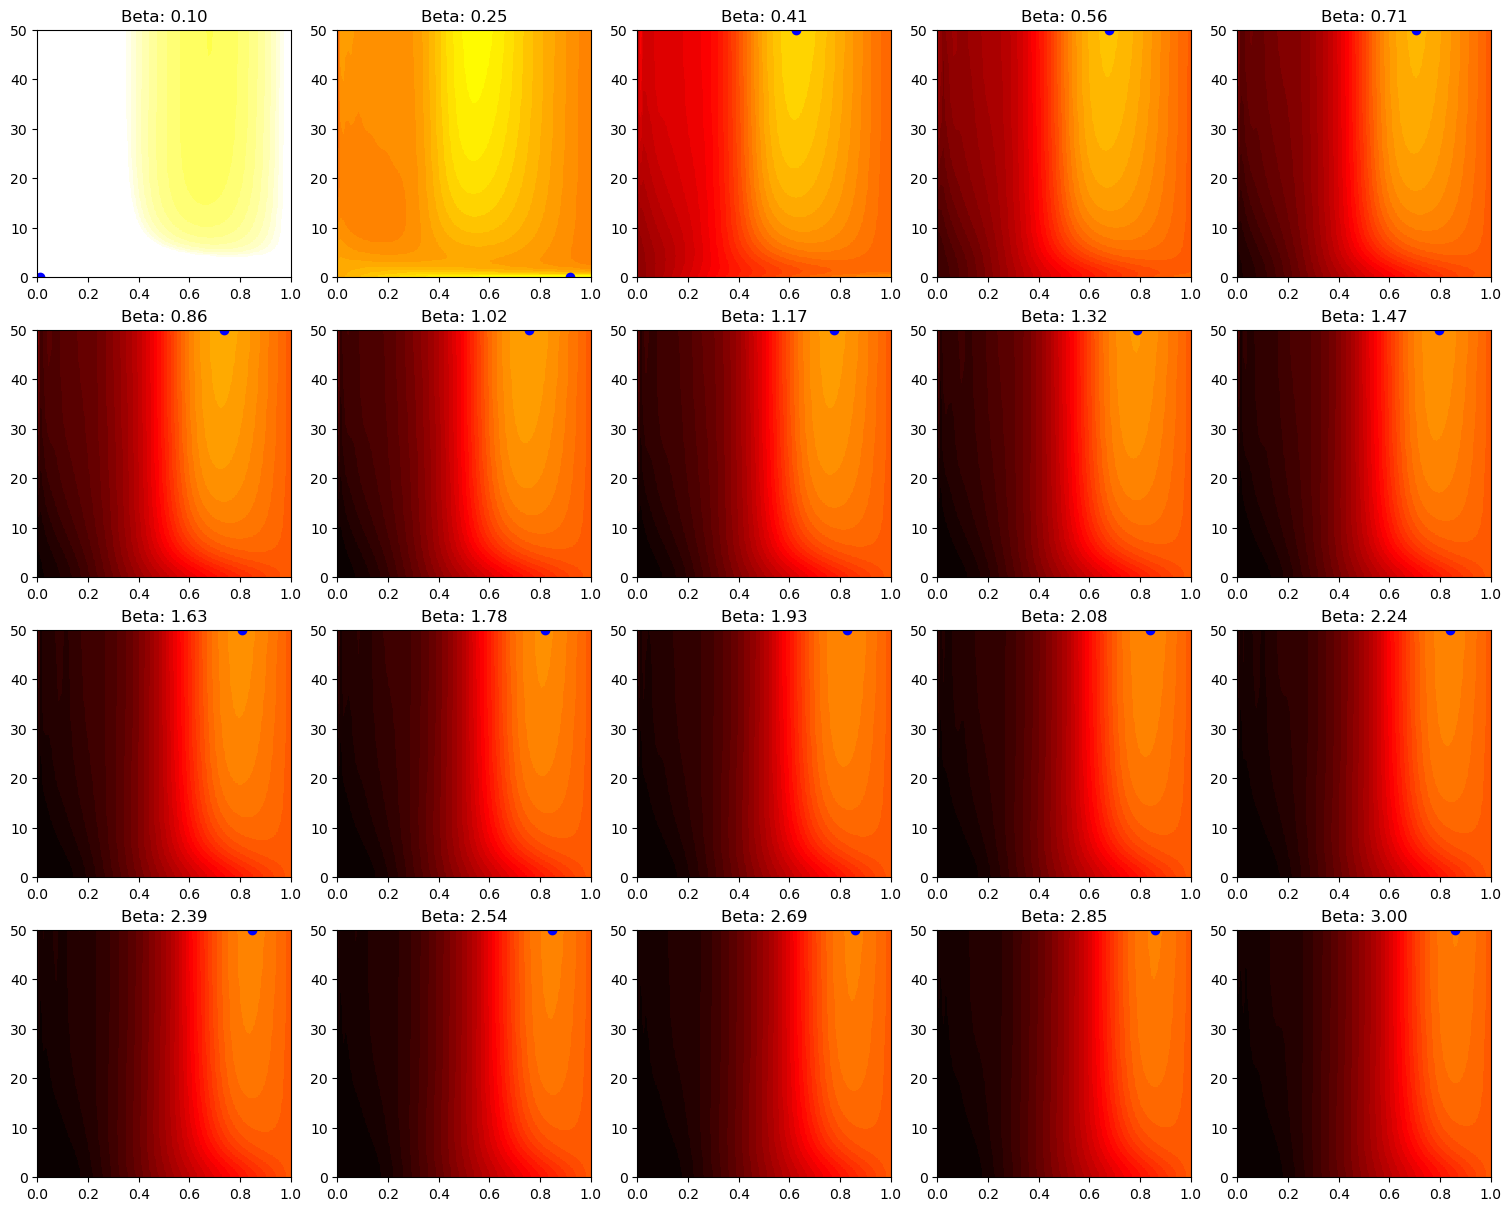

In [55]:
fig, axs = plt.subplots(4,5, figsize=(15,12), constrained_layout=True)
coords = [(i // 5, i % 5) for i in range(20)]
for i in range(len(betas)):
    row, col = coords[i]
    ax = axs[row, col]
    RM_1_L = ALL_RES[i]
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    # calculate the maximum value of homophily where I(pol=0)<=I(pol>0)
    im = ax.imshow(TI, origin='lower', extent=(0,1,0,50), aspect='auto', cmap=my_map, vmin = 0, vmax = 1)
    ax.set_title(f"Beta: {betas[i]:.2f}")
    ax.scatter([min_POL2[i]], [min_HOM2[i]], color='blue')

(0.0, 1.0)

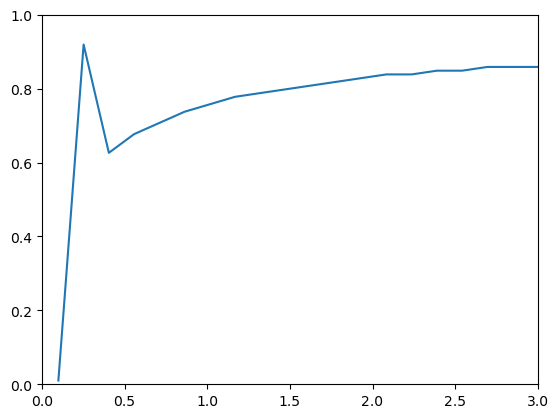

In [58]:
fig, ax =plt.subplots()

ax.plot(betas,min_POL2)
ax.set_xlim(0,3)
ax.set_ylim(0,1)

In [33]:
temp = read_json("./parameters2.json")
mus, taus, xis, PARAMS = temp["mus"], temp["taus"], temp["xis"], temp["PARAMS"]

In [42]:
betas = np.linspace(0.1, 1, 20)
PS = 11
i = 0

min_POL2 = np.zeros(len(betas))
max_POL2 = np.zeros(len(betas))

min_HOM2 = np.zeros(len(betas))
max_HOM2 = np.zeros(len(betas))
ALL_RES = []
NP = 99
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 100, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    ALL_RES.append(RM_1_L)
    max_POL2[i], max_HOM2[i], min_POL2[i], min_HOM2[i] = calculate_min_max(RM_1_L, pol_range, homophilic_tendency)
    i += 1

0.1
0.1473684210526316
0.19473684210526315
0.24210526315789474
0.2894736842105263
0.33684210526315794
0.38421052631578945
0.43157894736842106
0.4789473684210527
0.5263157894736842
0.5736842105263158
0.6210526315789474
0.6684210526315789
0.7157894736842105
0.7631578947368421
0.8105263157894737
0.8578947368421053
0.9052631578947369
0.9526315789473684
1.0


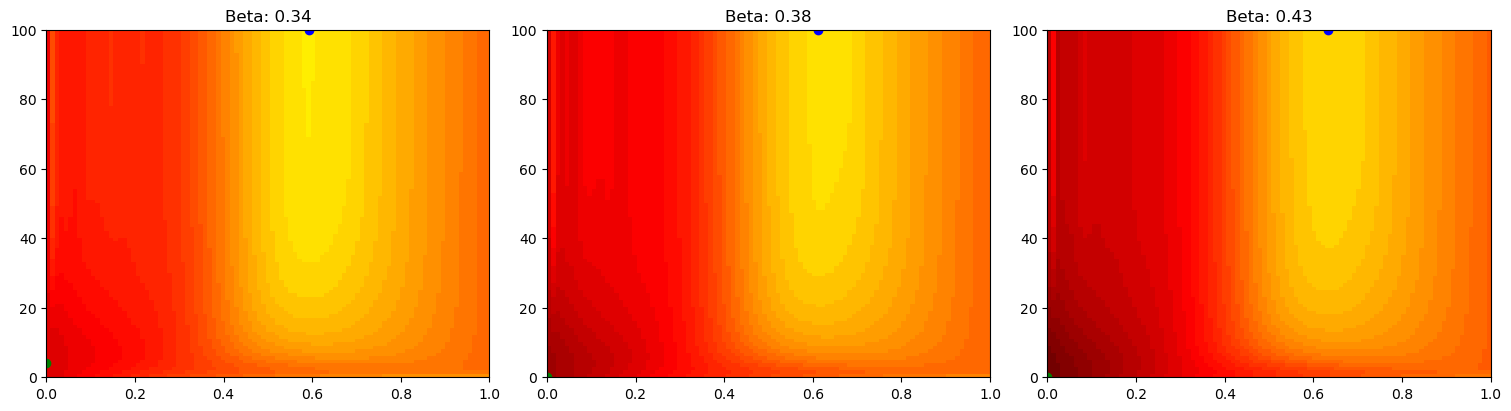

In [43]:
interesting_indexes = [5,6,7]
fig, axs = plt.subplots(1, len(interesting_indexes), figsize=(15,4), constrained_layout=True)
for i, indx in enumerate(interesting_indexes):
    ax = axs[i]
    RM_1_L = ALL_RES[indx]
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)

    im = ax.imshow(TI, origin='lower', extent=(0,1,0,100), aspect='auto', cmap=my_map, vmin = 0, vmax = 1)
    ax.set_title(f"Beta: {betas[indx]:.2f}")
    ax.scatter([min_POL2[indx]], [min_HOM2[indx]], color='blue')
    ax.scatter([max_POL2[indx]], [max_HOM2[indx]], color='green')

(100, 99, 31)
(100, 99, 31)
(100, 99, 31)


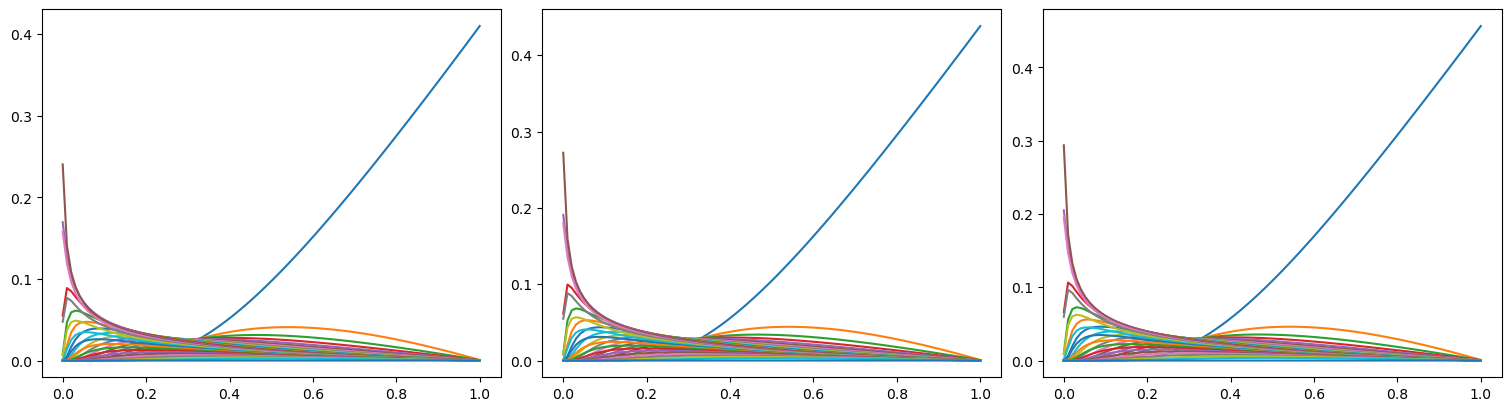

In [41]:
interesting_indexes = [5,6,7]
fig, axs = plt.subplots(1, len(interesting_indexes), figsize=(15,4), constrained_layout=True)
pols = np.linspace(0, 1, NP)
for i, indx in enumerate(interesting_indexes):
    ax = axs[i]
    RM_1_L = ALL_RES[indx]
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    print(TI.shape)
    for j in range(TI.shape[2]):
        axs[i].plot(pols, TI[0,:,j])

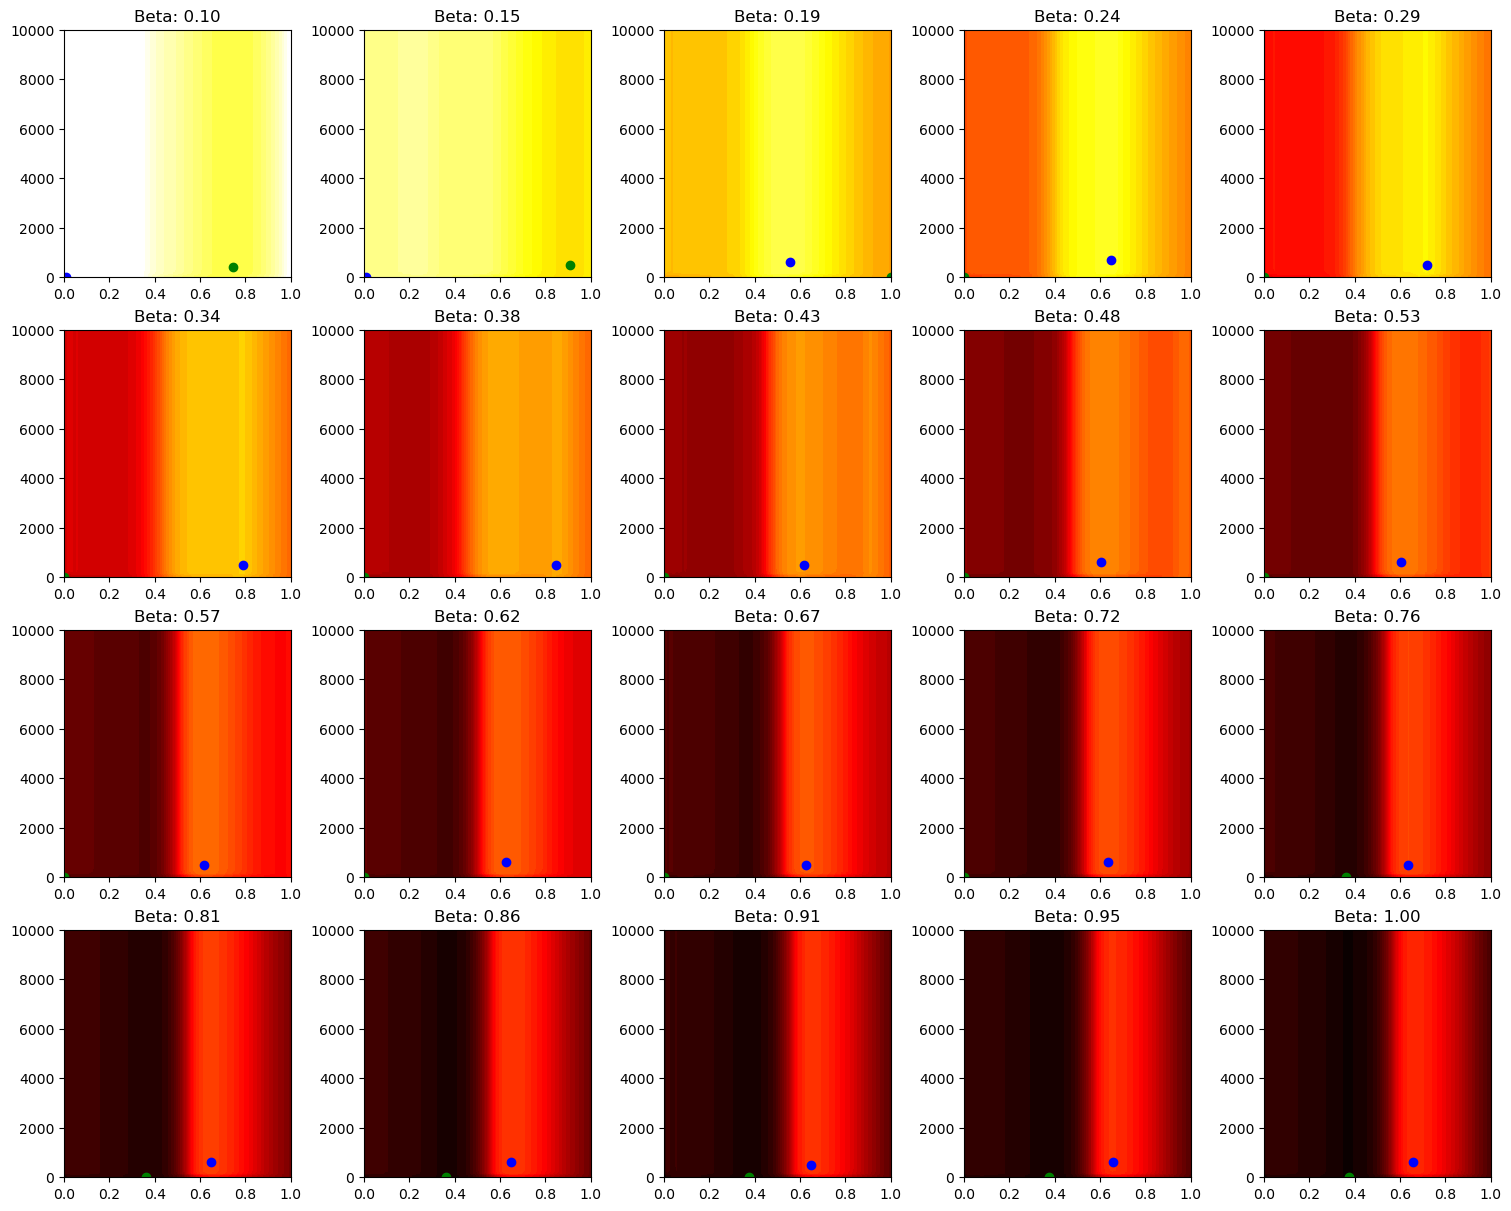

In [31]:
fig, axs = plt.subplots(4,5, figsize=(15,12), constrained_layout=True)
coords = [(i // 5, i % 5) for i in range(20)]
for i in range(len(betas)):
    row, col = coords[i]
    ax = axs[row, col]
    RM_1_L = ALL_RES[i]
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)

    im = ax.imshow(TI, origin='lower', extent=(0,1,0,10000), aspect='auto', cmap=my_map, vmin = 0, vmax = 1)
    ax.set_title(f"Beta: {betas[i]:.2f}")
    ax.scatter([min_POL2[i]], [min_HOM2[i]], color='blue')
    ax.scatter([max_POL2[i]], [max_HOM2[i]], color='green')

Text(0.5, 1.0, 'maximize(I+R)')

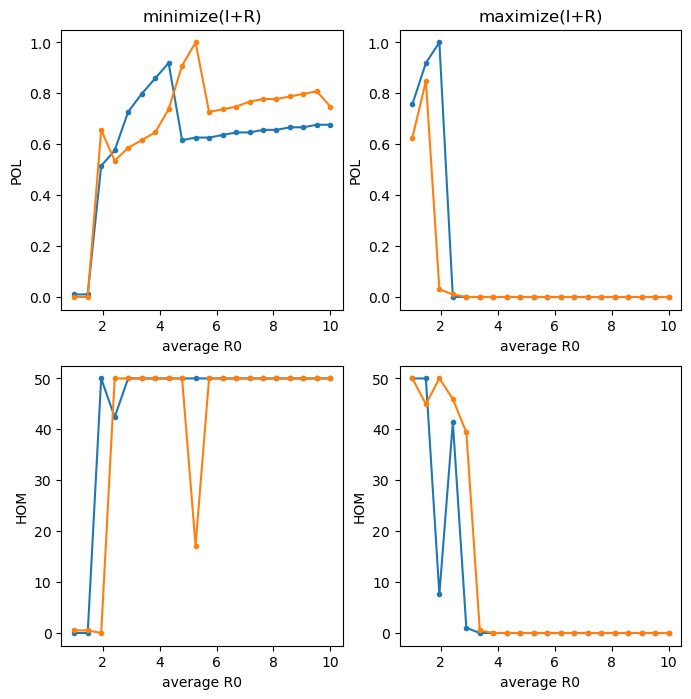

In [8]:
fig, ax = plt.subplots(2,2,figsize=(8,8))
betas = np.linspace(0.1, 1, 20)
ax[0][0].plot(betas*10, min_POL2,'.-')
ax[0,0].plot(betas*10,min_POL3,'.-')
ax[0][0].set_xlabel("average R0")
ax[0][0].set_ylabel("POL")

ax[0][1].plot(betas*10, max_POL2,'.-')
ax[0,1].plot(betas*10,  max_POL3,'.-')

ax[0][1].set_xlabel("average R0")
ax[0][1].set_ylabel("POL")



ax[1][0].plot(betas*10, min_HOM2,'.-')
ax[1,0].plot(betas*10,min_HOM3,'.-')

ax[1][0].set_xlabel("average R0")
ax[1][0].set_ylabel("HOM")

ax[1][1].plot(betas*10, max_HOM2,'.-')
ax[1,1].plot(betas*10,max_HOM3,'.-')

ax[1][1].set_xlabel("average R0")
ax[1][1].set_ylabel("HOM")

ax[0,0].set_title("minimize(I+R)")
ax[0,1].set_title("maximize(I+R)")



In [9]:
betas = [0.2]

NP = 100
NH = 100
PS = 101
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 50, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )


0.2


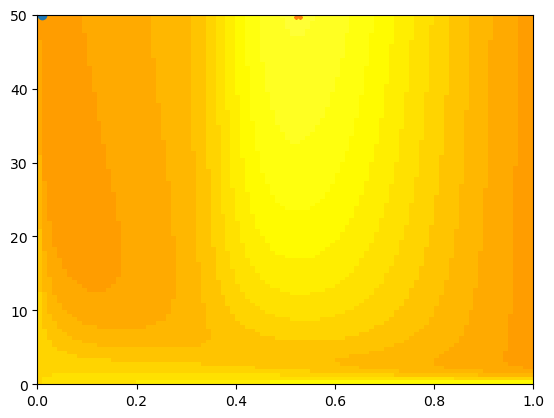

In [12]:
TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
TI = np.sum(TI, axis=2)
fig, ax = plt.subplots()
ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 50],
    aspect='auto')


max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
ax.plot(max_pol, max_homophily, 'o')


min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
ax.plot(min_pol,min_homophily,'X')

Text(0, 0.5, 'value of polarization that maximize infection')

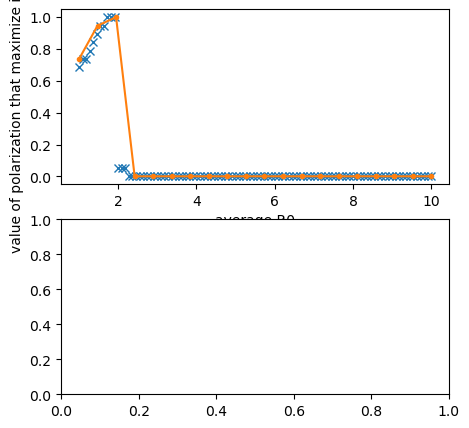

In [6]:
betas = np.linspace(0.1, 10, 100)
PS = 11
i = 0

min_POL_T = np.zeros(len(betas))
max_POL_T = np.zeros(len(betas))

min_HOM_T = np.zeros(len(betas))
max_HOM_T = np.zeros(len(betas))

NP = 50
NH = 50
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 20, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.1
    RM_1_L = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    max_POL_T[i] = max_pol
    max_HOM_T[i] = max_homophily


    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    min_POL_T[i] = min_pol
    min_HOM_T[i] = min_homophily
    i += 1

0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9
1.0
1.1
1.2000000000000002
1.3000000000000003
1.4000000000000001
1.5000000000000002
1.6
1.7000000000000002
1.8000000000000003
1.9000000000000001
2.0
2.1
2.2
2.3000000000000003
2.4000000000000004
2.5000000000000004
2.6
2.7
2.8000000000000003
2.9000000000000004
3.0000000000000004
3.1
3.2
3.3000000000000003
3.4000000000000004
3.5000000000000004
3.6
3.7
3.8000000000000003
3.9000000000000004
4.0
4.1
4.2
4.3
4.3999999999999995
4.5
4.6
4.7
4.8
4.9
5.0
5.1
5.2
5.3
5.4
5.5
5.6
5.7
5.8
5.9
6.0
6.1
6.2
6.3
6.4
6.5
6.6
6.7
6.8
6.9
7.0
7.1
7.2
7.3
7.4
7.5
7.6
7.7
7.8
7.9
8.0
8.1
8.2
8.3
8.4
8.5
8.6
8.7
8.8
8.9
9.0
9.1
9.2
9.3
9.4
9.5
9.6
9.700000000000001
9.8
9.9
10.0


In [7]:
betas = np.linspace(0.1, 10, 100)
PS = 11
i = 0

min_POL_V = np.zeros(len(betas))
max_POL_V = np.zeros(len(betas))

min_HOM_V = np.zeros(len(betas))
max_HOM_V = np.zeros(len(betas))

NP = 50
NH = 50
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 20, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.1
    RM_1_L = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    max_POL_V[i] = max_pol
    max_HOM_V[i] = max_homophily


    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    min_POL_V[i] = min_pol
    min_HOM_V[i] = min_homophily
    i += 1

0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9
1.0
1.1
1.2000000000000002
1.3000000000000003
1.4000000000000001
1.5000000000000002
1.6
1.7000000000000002
1.8000000000000003
1.9000000000000001
2.0
2.1
2.2
2.3000000000000003
2.4000000000000004
2.5000000000000004
2.6
2.7
2.8000000000000003
2.9000000000000004
3.0000000000000004
3.1
3.2
3.3000000000000003
3.4000000000000004
3.5000000000000004
3.6
3.7
3.8000000000000003
3.9000000000000004
4.0
4.1
4.2
4.3
4.3999999999999995
4.5
4.6
4.7
4.8
4.9
5.0
5.1
5.2
5.3
5.4
5.5
5.6
5.7
5.8
5.9
6.0
6.1
6.2
6.3
6.4
6.5
6.6
6.7
6.8
6.9
7.0
7.1
7.2
7.3
7.4
7.5
7.6
7.7
7.8
7.9
8.0
8.1
8.2
8.3
8.4
8.5
8.6
8.7
8.8
8.9
9.0
9.1
9.2
9.3
9.4
9.5
9.6
9.700000000000001
9.8
9.9
10.0


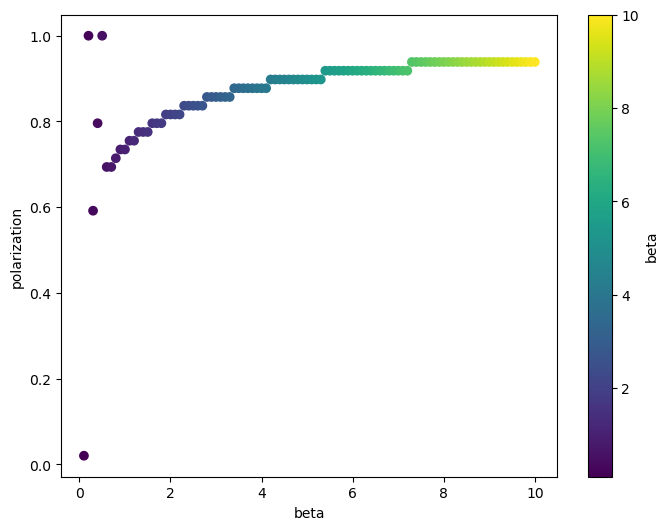

In [8]:
plt.figure(figsize=(8,6))

# Color points by beta instead of index
plt.scatter(betas, min_POL, c=betas, cmap='viridis')

plt.colorbar(label="beta")
plt.xlabel("beta")
plt.ylabel("polarization")
plt.show()

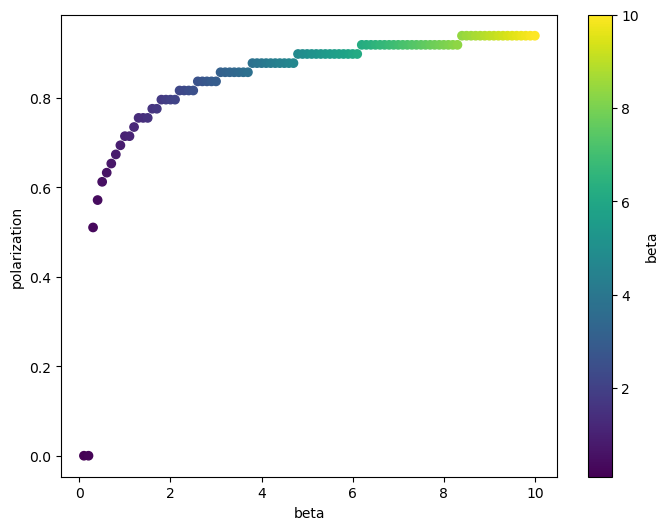

In [11]:
plt.figure(figsize=(8,6))

# Color points by beta instead of index
plt.scatter(betas, min_POL_T, c=betas, cmap='viridis')

plt.colorbar(label="beta")
plt.xlabel("beta")
plt.ylabel("polarization")
plt.show()

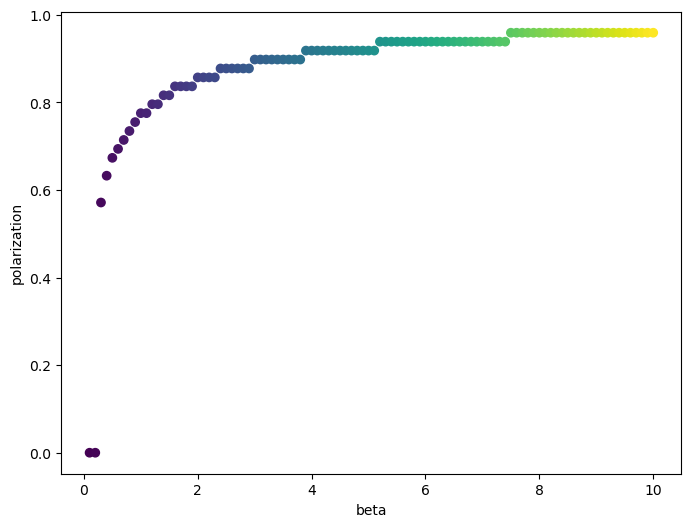

In [13]:
plt.figure(figsize=(8,6))

# Color points by beta instead of index
plt.scatter(betas, min_POL_V, c=betas, cmap='viridis')
plt.xlabel("beta")
plt.ylabel("polarization")
plt.show()
plt.show()

In [ ]:
betas = np.linspace(0.1, 1, 50)
PS = 21
i = 0

min_POL_M = np.zeros(len(betas))
max_POL_M = np.zeros(len(betas))

min_HOM_M = np.zeros(len(betas))
max_HOM_M = np.zeros(len(betas))

NP = 20
NH = 20
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 30, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.1
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=400
    )
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    max_POL_M[i] = max_pol
    max_HOM_M[i] = max_homophily


    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    min_POL_M[i] = min_pol
    min_HOM_M[i] = min_homophily
    i += 1

0.1
0.11836734693877551
0.13673469387755102
0.15510204081632656


In [14]:
betas = np.linspace(0.1, 0.5, 50)
PS = 11
i = 0

min_POL_T = np.zeros(len(betas))
max_POL_T = np.zeros(len(betas))

min_HOM_T = np.zeros(len(betas))
max_HOM_T = np.zeros(len(betas))

NP = 50
NH = 50
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 30, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.5
    RM_1_L = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    max_POL_T[i] = max_pol
    max_HOM_T[i] = max_homophily


    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    min_POL_T[i] = min_pol
    min_HOM_T[i] = min_homophily
    i += 1

0.1
0.10816326530612246
0.1163265306122449
0.12448979591836735
0.1326530612244898
0.14081632653061227
0.1489795918367347
0.15714285714285714
0.1653061224489796
0.17346938775510207
0.1816326530612245
0.18979591836734694
0.1979591836734694
0.20612244897959187
0.2142857142857143
0.22244897959183674
0.2306122448979592
0.23877551020408164
0.2469387755102041
0.2551020408163266
0.263265306122449
0.27142857142857146
0.2795918367346939
0.28775510204081634
0.29591836734693877
0.3040816326530612
0.3122448979591837
0.3204081632653062
0.3285714285714286
0.33673469387755106
0.3448979591836735
0.35306122448979593
0.36122448979591837
0.3693877551020408
0.37755102040816324
0.3857142857142858
0.3938775510204082
0.40204081632653066
0.4102040816326531
0.41836734693877553
0.42653061224489797
0.4346938775510204
0.44285714285714284
0.4510204081632654
0.4591836734693878
0.46734693877551026
0.4755102040816327
0.48367346938775513
0.49183673469387756
0.5


In [ ]:
betas = np.linspace(0.1, 0.5, 50)
PS = 11
i = 0

min_POL_V = np.zeros(len(betas))
max_POL_V = np.zeros(len(betas))

min_HOM_V = np.zeros(len(betas))
max_HOM_V = np.zeros(len(betas))

NP = 50
NH = 50
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 30, "n": NH}
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.5
    RM_1_L = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    max_POL_V[i] = max_pol
    max_HOM_V[i] = max_homophily


    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    min_POL_V[i] = min_pol
    min_HOM_V[i] = min_homophily
    i += 1

0.1
0.10816326530612246
0.1163265306122449
0.12448979591836735
0.1326530612244898
0.14081632653061227
0.1489795918367347
0.15714285714285714
0.1653061224489796
0.17346938775510207
0.1816326530612245
0.18979591836734694
0.1979591836734694
0.20612244897959187
0.2142857142857143
0.22244897959183674
0.2306122448979592
0.23877551020408164
0.2469387755102041
0.2551020408163266
0.263265306122449
0.27142857142857146
0.2795918367346939
0.28775510204081634
0.29591836734693877
0.3040816326530612
0.3122448979591837
0.3204081632653062
0.3285714285714286
0.33673469387755106
0.3448979591836735
0.35306122448979593
0.36122448979591837
0.3693877551020408
0.37755102040816324
0.3857142857142858
0.3938775510204082
0.40204081632653066
0.4102040816326531
0.41836734693877553
0.42653061224489797
0.4346938775510204
0.44285714285714284
0.4510204081632654
0.4591836734693878
0.46734693877551026
0.4755102040816327
0.48367346938775513
0.49183673469387756
0.5


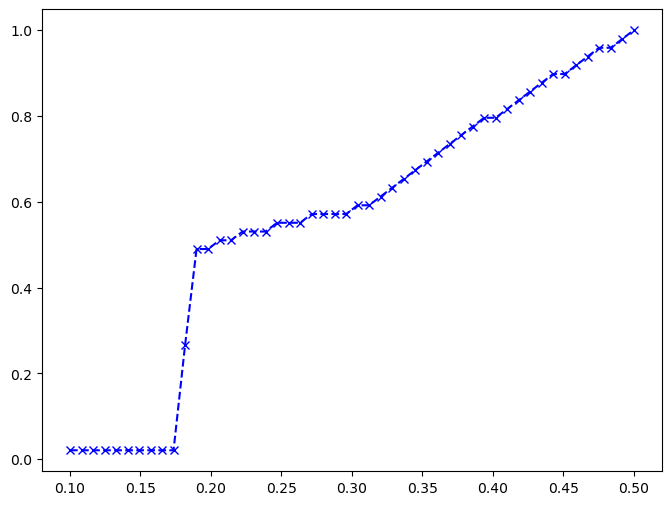

In [17]:
betas = np.linspace(0.1, 0.5, 50)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(betas,min_POL_M, 'x', label='SIRM dT=0.5', color='blue', linestyle='--')

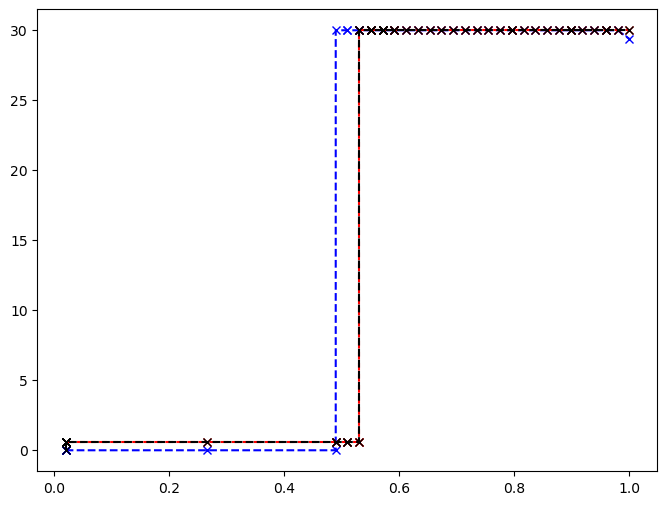

In [16]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(min_POL_M, min_HOM_M, 'x', color='blue', linestyle='--')
ax.plot(min_POL_M, min_HOM_T, 'x', color='red', linestyle='--')
ax.plot(min_POL_M, min_HOM_V, 'x', color='black', linestyle='--')


0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55


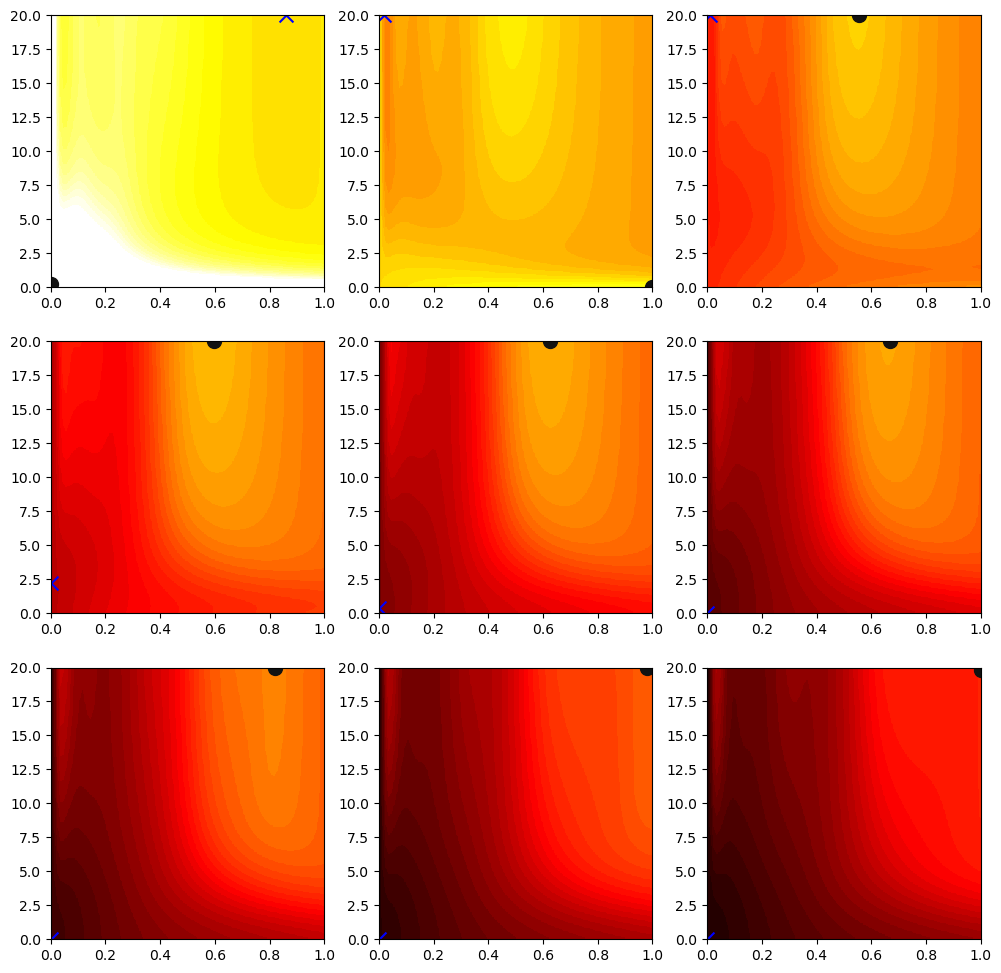

In [42]:
betas = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
PS = 5
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
i = 0

for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    PARAMS["dT"] = 0.5
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    coords = [(i // 3, i % 3) for i in range(9)]
    i=i+1
    TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
    TI = np.sum(TI, axis=2)
    ax = axs[coords[i-1][0], coords[i-1][1]]
    ax.imshow(
        TI, vmin = 0, vmax = 1, cmap = my_map,
        origin='lower', extent=[0, 1, 0, 20],
        aspect='auto')
    # find maximum infection point    # print coordinates of maximum infection point
    max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
    max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
    max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
    ax.scatter(max_pol, max_homophily, color='blue', marker='x', s=100)

    # find minimum infection point
    min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
    min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
    min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
    ax.scatter(min_pol, min_homophily, marker='o', s=100, color ="#121212")



0.15
min-max range: 0.0009915233  to  0.3021438  -- max variation --  30.0
0.2


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


min-max range: 0.26542342  to  0.4442634  -- max variation --  18.0
0.4
min-max range: 0.36995435  to  0.8815784  -- max variation --  51.0


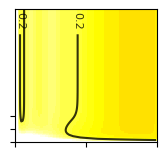

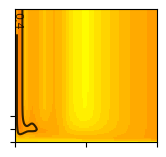

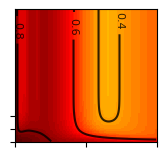

In [36]:
betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = 0.5
PS = 5
for beta in betas:
    print(beta)
    
    path = "figures/Fig_2/I(pol,hom,mean)_M_" + str(np.round(beta,2)) + ".pdf"
    PARAMS["beta_M"] = beta
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    fig_R_M_1_L = plot_multiple_metrics(
        RM_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        #save_path=path
    )

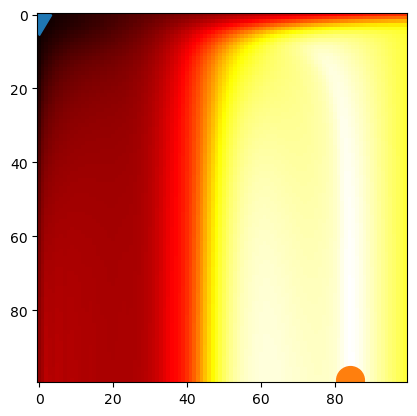

In [17]:
TI = RM_1_L["final_state"]["R"] + RM_1_L["final_state"]["I"]
TI = np.sum(TI,2)
fig, ax = plt.subplots()

ax.imshow(TI, cmap="hot_r")

row, col = np.unravel_index(np.argmax(TI), TI.shape)
ax.plot(col, row, "d", markersize = 20)

row, col = np.unravel_index(np.argmin(TI), TI.shape)
ax.plot(col, row, "o", markersize = 20)


In [ ]:


betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = 0.5
for beta in betas:
    print(beta)
    
    path = "figures/Fig_2/I(pol,hom,mean)_T_" + str(np.round(beta,2)) + ".pdf"
    PARAMS["beta_M"] = beta
    RT_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=10000,
    initial_infected_prop = 1e-4
)
    fig_R_T_1_L = plot_multiple_metrics(
        RT_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        #save_path=path
    )

: 

In [ ]:
betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = 0.5
for beta in betas:
    print(beta)
    PARAMS["beta_M"] = beta
    
    path = "figures/Fig_2/I(pol,hom,mean)_V_" + str(np.round(beta,2)) + ".pdf"
    rv = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=10000,
        initial_infected_prop=1e-4        
    )
    fig_R_T_1_L = plot_multiple_metrics(
        rv, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        #save_path=path
    )

: 

(100, 100, 20)


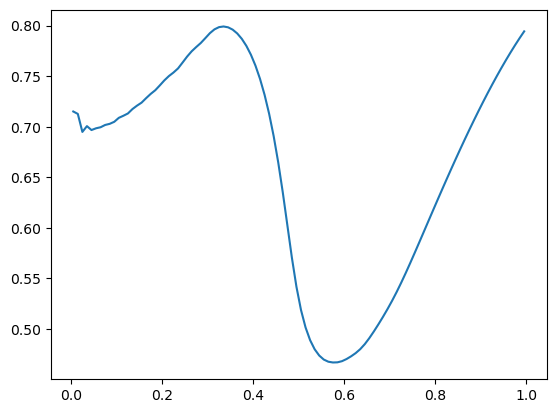

In [184]:
from src.utils.distributions import homogeneous_distribution
R_inf = rv['final_state']['I'] + rv['final_state']['R']
print(R_inf.shape)

plt.plot(homogeneous_distribution(
                pol_range["n"], pol_range["m"], pol_range["M"]
            ),np.sum(R_inf,2)[-5,:])

In [155]:
NB = 100
NP = 100

PS = 5

homophilic_tendency = {"m": 0, "M": 6, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PARAMS["fixed_mean"] = 0.5
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.2, 0.4, 0.6, 0.8]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx/1.25,  # Figure width in inches
        'Ly': Ly/1.25,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 3, 6],
        'xlim': [0, 1],
        'ylim': [0, 6]
    }

0.15
min-max range: 0.00015968084  to  0.00025123358  -- max variation --  0.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


0.2
min-max range: 0.00020110607  to  0.0005710125  -- max variation --  0.0
0.4
min-max range: 0.056649268  to  0.5905293  -- max variation --  53.0


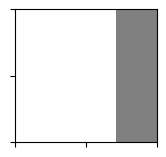

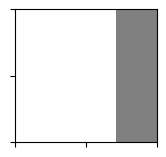

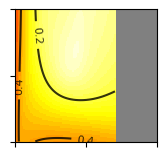

In [148]:
betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = mus["mean"][1]
for beta in betas:
    print(beta)
    
    path = "figures/Fig_3/I(pol,hom,mean)_M_" + str(np.round(beta,2)) + ".pdf"
    PARAMS["beta_M"] = beta
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    fig_R_M_1_L = plot_multiple_metrics(
        RM_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        save_path=path
    )

0.15
min-max range: 0.00041228533  to  0.35209548  -- max variation --  35.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


0.2
min-max range: 0.024546385  to  0.57083035  -- max variation --  55.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


0.4
min-max range: 0.71458256  to  0.929434  -- max variation --  21.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


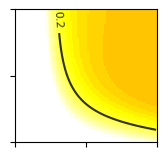

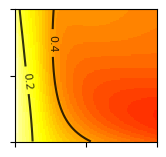

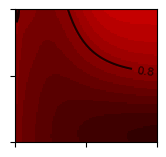

In [149]:
betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = taus["mean"][1]
PS = 5
for beta in betas:
    print(beta)
    
    path = "figures/Fig_3/I(pol,hom,mean)_T_" + str(np.round(beta,2)) + ".pdf"
    PARAMS["beta_M"] = beta
    RM_1_L = sweep_two_parameters(
        model_module=SIRT,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    fig_R_M_1_L = plot_multiple_metrics(
        RM_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        save_path=path
    )

0.15
min-max range: 0.0039547086  to  0.08376086  -- max variation --  8.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


0.2
min-max range: 0.06980842  to  0.28438467  -- max variation --  21.0
0.4
min-max range: 0.74221337  to  0.78925705  -- max variation --  5.0


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:267: UserWarning: The following kwargs were not used by contour: 'rasterized'
  colors=contour_colors,


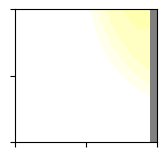

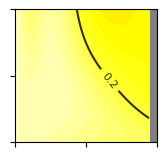

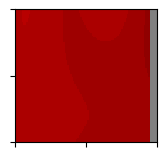

In [150]:
betas = [0.15, 0.2, 0.4]
PARAMS["fixed_mean"] = xis["mean"][1]
PS = 5
for beta in betas:
    print(beta)
    
    path = "figures/Fig_3/I(pol,hom,mean)_V_" + str(np.round(beta,2)) + ".pdf"
    PARAMS["beta_M"] = beta
    RM_1_L = sweep_two_parameters(
        model_module=SIRV,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    fig_R_M_1_L = plot_multiple_metrics(
        RM_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        save_path=path
    )

In [ ]:


PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = 0.5
RM_1_L = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RM_1_H = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=10000
)

PARAMS["fixed_mean"] = mus["mean"][1]
RM_2 = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=1000
)
PARAMS["beta_M"] = 0.2



In [21]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 12, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}

PARAMS["fixed_mean"] = 0.5
RT_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RT_1_H = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=10000
)


PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = taus["mean"][1]
RT_2 = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=5,
    batch_size=10000
)





In [60]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 12, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}


PS = 5


PARAMS["fixed_mean"] = 0.5
PARAMS["beta_M"] = 0.2
RV_1_L_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)

PARAMS["beta_M"] = 0.4
RV_1_H_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)



PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = xis["mean"][1]

RV_2_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)

PARAMS["fixed_mean"] = 0.5
PARAMS["beta_M"] = 0.2
RV_1_L_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)

PARAMS["beta_M"] = 0.4
RV_1_H_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)



PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = xis["mean"][1]

RV_2_5 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=1000
)




In [23]:
# visualization parameters

colors_X = ['#66c2a4', '#238b45','#00441b']  # fixed polarization
colors_Y = ['#67001f', '#e7298a', '#df65b0'] # fixed homophily
my_map = discretize_cmaps("hot_r",51)
my_map.set_bad(color='gray')
cmaps = [my_map]
contour_values = [[0.25, 0.5, 0.75]]
contour_colors = [['#000','#000','#000']]
final_params={
        'Lx': Lx,  # Figure width in inches
        'Ly': Ly,  # Figure height in inches
        'xticks': [0, 0.5, 1.0],
        'yticks': [0, 6, 12],
        'xlim': [0, 1],
        'ylim': [0, 12]
    }

0.15


c:\users\nel_t\documents\work\projects\pol_hom - copia\src\utils\visualization\common.py:264: UserWarning: The following kwargs were not used by contour: 'rasterized'
  contour = ax.contour(


0.2
0.3


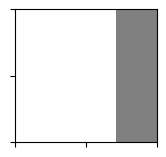

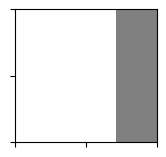

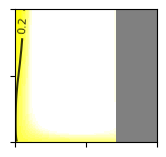

In [94]:


betas = [0.15, 0.2, 0.3]
PS = 20
for beta in betas:
    print(beta)
    
    path = "figures/Fig_3/I(pol,hom,mean)_M_" + str(np.round(beta,2)) + ".pdf"
    PARAMS['fixed_mean'] = mus["mean"][1]
    PARAMS["beta_M"] = beta
    RM_1_L = sweep_two_parameters(
        model_module=SIRM,
        param1_name="beta_params",           # parameter 1 name
        param1_range=pol_range,    # parameter 1 range
        param2_name="homophilic_tendency",      # parameter 2 name
        param2_range=homophilic_tendency,         # parameter 2 range
        custom_base_params=PARAMS,
        simulated_days=1000,
        population_size=PS,
        batch_size=2500
    )
    fig_R_M_1_L = plot_multiple_metrics(
        RM_1_L, 
        metrics=["infections"],
        cmaps=cmaps, 
        contour_values=contour_values,
        contour_colors=contour_colors,
        final_params=final_params,
        save_path=path
    )

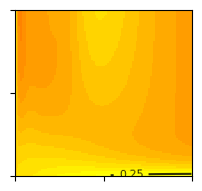

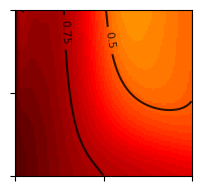

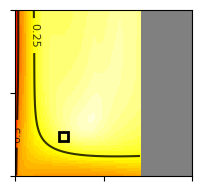

In [29]:
fig_R_M_1_L = plot_multiple_metrics(
    RM_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_M_1_H = plot_multiple_metrics(
    RM_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T
)
fig_R_M_2 = plot_multiple_metrics(
    RM_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M
)

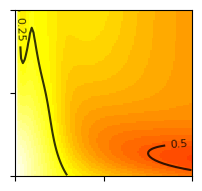

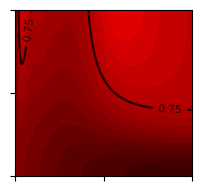

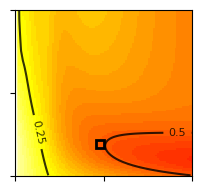

In [25]:

fig_R_T_1_L = plot_multiple_metrics(
    RT_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_T_1_H = plot_multiple_metrics(
    RT_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_T_2 = plot_multiple_metrics(
    RT_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_T
)

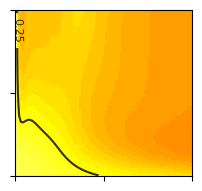

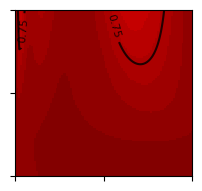

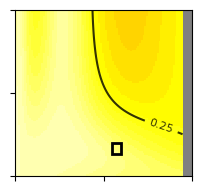

In [ ]:
fig_R_V_1 = plot_multiple_metrics(
    RV_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_V_H = plot_multiple_metrics(
    RV_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)


fig_R_V_2 = plot_multiple_metrics(
    RV_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_V
)

# PS = 10

In [27]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 12, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}
PARAMS["beta_M"] = 0.2



PARAMS["fixed_mean"] = 0.5
RM_1_L = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RM_1_H = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=10000
)

PARAMS["fixed_mean"] = mus["mean"][1]
RM_2 = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=1000
)
PARAMS["beta_M"] = 0.2



In [31]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 12, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}

PARAMS["fixed_mean"] = 0.5
RT_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=10000
)
PARAMS["beta_M"] = 0.4
RT_1_H = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=10000
)


PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = taus["mean"][1]
RT_2 = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=10000
)




In [32]:
NB = 100
NP = 100

homophilic_tendency = {"m": 0, "M": 12, "n": NB}
pol_range = {"m": 0, "M": 1, "n": NP}

PARAMS["fixed_mean"] = 0.5
PARAMS["beta_M"] = 0.2
RV_1_L = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=1000
)

PARAMS["beta_M"] = 0.4
RV_1_H = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=1000
)



PARAMS["beta_M"] = 0.2
PARAMS["fixed_mean"] = xis["mean"][1]

RV_2 = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=10,
    batch_size=1000
)


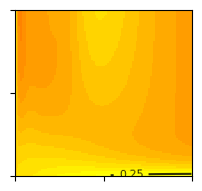

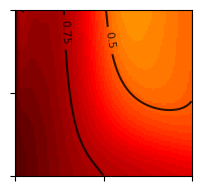

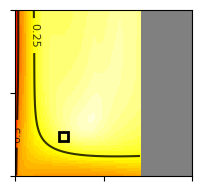

In [33]:
fig_R_M_1_L = plot_multiple_metrics(
    RM_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_M_1_H = plot_multiple_metrics(
    RM_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    #rect_coords = rect_coords_T
)
fig_R_M_2 = plot_multiple_metrics(
    RM_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_M
)

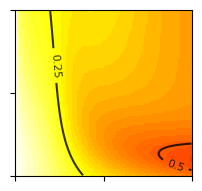

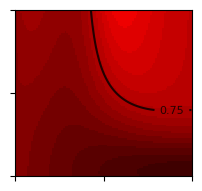

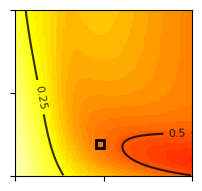

In [34]:

fig_R_T_1_L = plot_multiple_metrics(
    RT_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_T_1_H = plot_multiple_metrics(
    RT_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_T_2 = plot_multiple_metrics(
    RT_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_T
)

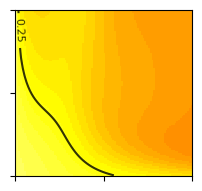

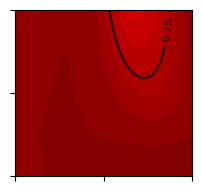

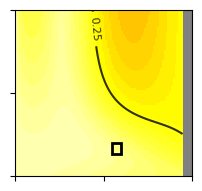

In [35]:
fig_R_V_1 = plot_multiple_metrics(
    RV_1_L, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)
fig_R_V_H = plot_multiple_metrics(
    RV_1_H, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params
)


fig_R_V_2 = plot_multiple_metrics(
    RV_2, 
    metrics=["infections"],
    cmaps=cmaps, 
    contour_values=contour_values,
    contour_colors=contour_colors,
    final_params=final_params,
    rect_coords = rect_coords_V
)

In [223]:
PS = 20
rm = sweep_two_parameters(
    model_module=SIRM,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=10000,
    initial_infected_prop=1e-4        
)

rt = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=10000,
    initial_infected_prop=1e-4        
)

rv = sweep_two_parameters(
    model_module=SIRV,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=10000,
    initial_infected_prop=1e-4        
)

In [230]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Define the two key colors
colors_custom_base = ['#00441b', '#99d8c9']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def create_interpolated_colormap(n_colors):
    """
    Create a list of n_colors by interpolating between the base colors
    """
    cmap = mcolors.LinearSegmentedColormap.from_list('custom', colors_custom_base)
    return [mcolors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n_colors)]

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot 3x2 grid:
    Top row: 3 infections by homophily plots (one per model)
    Bottom row: 3 r_inf(R0) plots (one per model)
    """
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    # Top row: infections by homophily
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        hom_values = hom_grid[:, pol_idx]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        n_compartments = R_slice.shape[1]
        
        # Generate interpolated colors
        compartment_colors = create_interpolated_colormap(n_compartments)
        
        for i in range(n_compartments):
            axs[0, col].plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(hom_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Homophilic Tendency')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: r_inf(R0) plots
    R0_values = np.linspace(0, 3, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    # Get colors for extreme compartments
    extreme_colors = create_interpolated_colormap(2)
    
    for col in range(3):
        axs[1, col].plot(R0_values, final_sizes, lw=3, color='#2166ac')
        axs[1, col].set_xlabel(r"$R_0$", fontsize=12)
        axs[1, col].set_ylabel(r"Final infected fraction $r_\infty$", fontsize=12)
        axs[1, col].set_title(f"Final epidemic size", fontsize=12)
        axs[1, col].grid(True, alpha=0.3)
    
    axs[1,0].plot(0.4,0,'o',markersize=10,color=extreme_colors[-1])
    axs[1,0].plot(2,0.8,'o',markersize=10,color=extreme_colors[0])
    
    axs[1,1].plot(0.2/(0.1+0.2),0,'o',markersize=10,color=extreme_colors[-1])
    axs[1,1].plot(2,0.8,'o',markersize=10,color=extreme_colors[0])
    
    axs[1,2].plot(2,0.8,'o',markersize=10,color=extreme_colors[-1])
    axs[1,2].plot(2,0.8,'o',markersize=10,color=extreme_colors[0])
    
    plt.tight_layout()
    return fig


def plot_infections_by_polarization_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, hom_value=6.0):
    """
    Plot 3x2 grid:
    Top row: 3 infections by polarization plots (one per model)
    Bottom row: 3 fraction infected by compartment plots (one per model)
    """
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    # Top row: infections by polarization
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        hom_values = hom_grid[:, 0]
        hom_idx = np.argmin(np.abs(hom_values - hom_value))
        print(hom_idx)
        
        pol_values = pol_grid[hom_idx, :]
        
        R_data = sweep_result["final_state"]["R"]+sweep_result["final_state"]["I"]
        print(R_data.shape)
        R_slice = R_data[hom_idx, :, :]
        
        n_compartments = R_slice.shape[1]
        
        # Generate interpolated colors
        compartment_colors = create_interpolated_colormap(n_compartments)
        
        for i in range(n_compartments):
            axs[col].plot(pol_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[col].plot(pol_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[col].set_xlabel('Polarization')
        axs[col].set_ylabel('Total Infections (Recovered)')
        axs[col].set_title(f'{model_name}\n(Homophily = {hom_value:.2f})')
        #axs[col].legend()
        axs[col].grid(True, alpha=0.3)
        axs[col].set_ylim([0, 1])
    
    plt.tight_layout()
    return fig

9
(100, 100, 20)
9
(100, 100, 20)
9
(100, 100, 20)


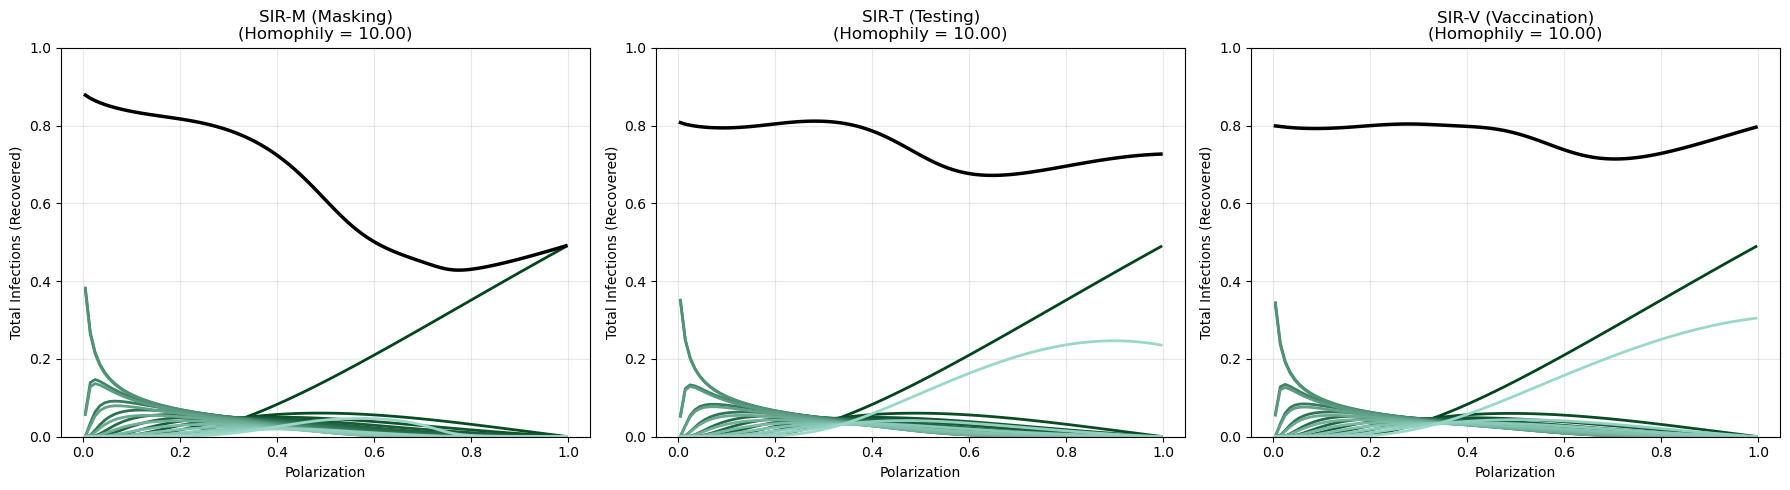

In [231]:
# Use it
fig = plot_infections_by_polarization_three_models(rm, rt, rv, hom_value=10)
plt.show()




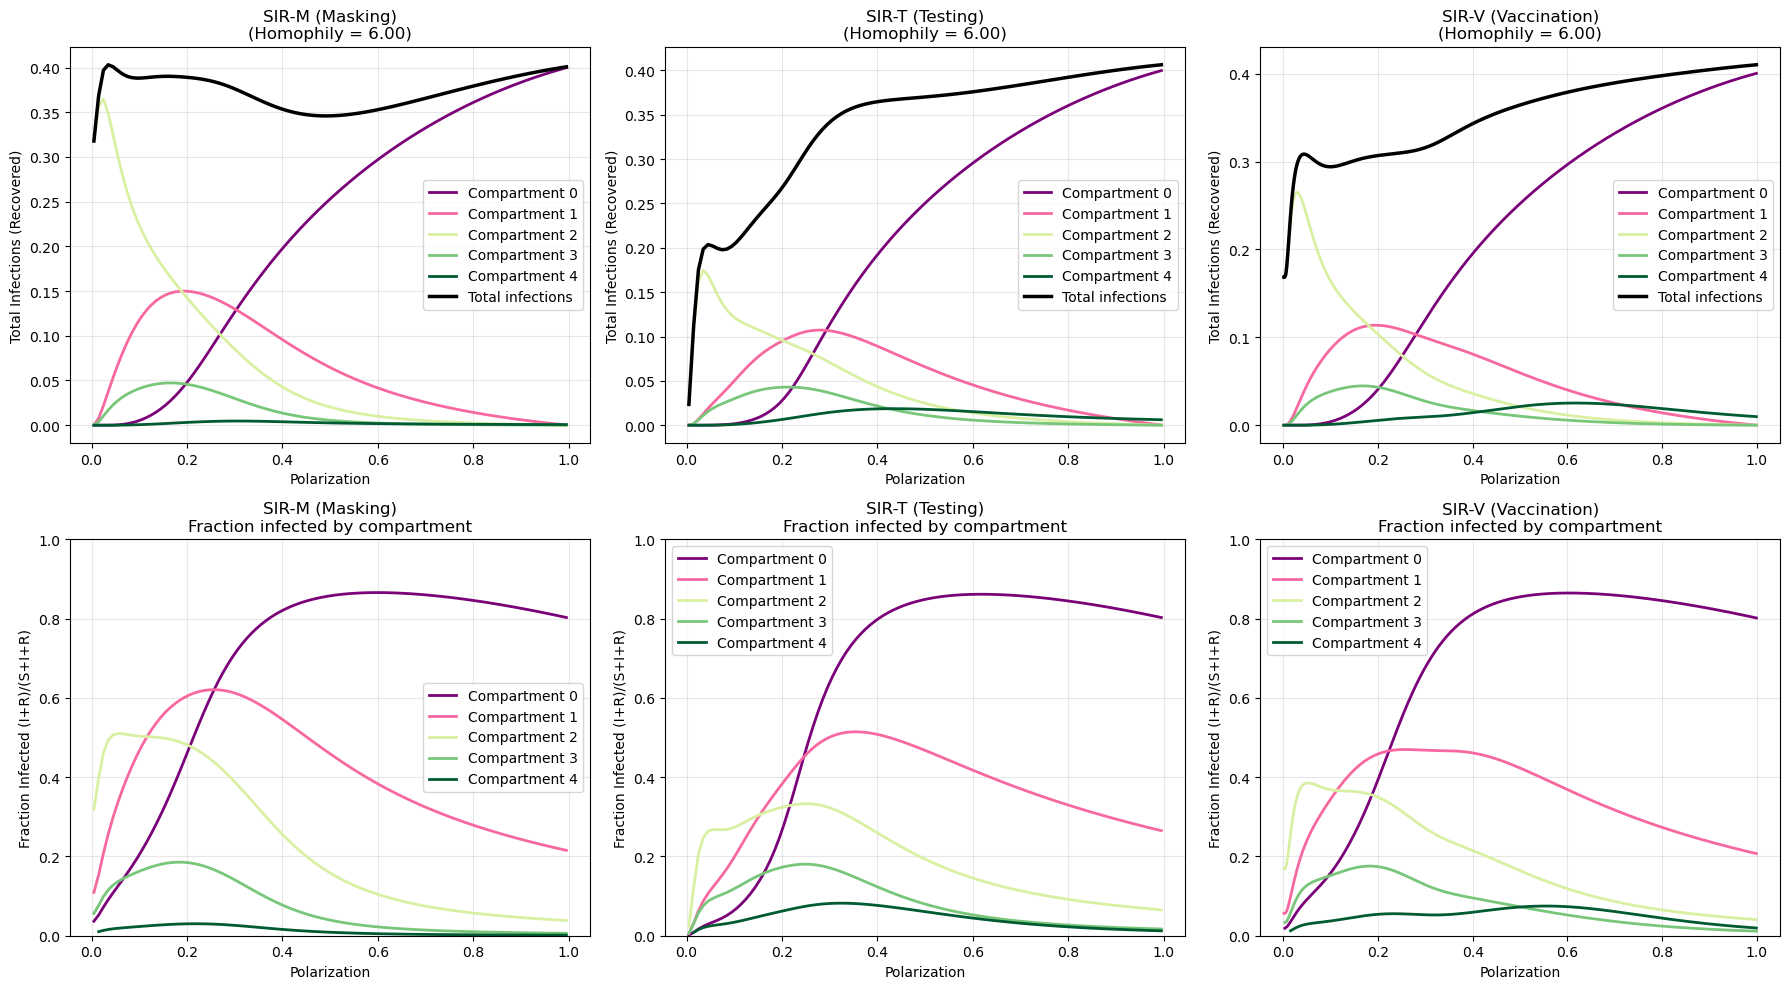

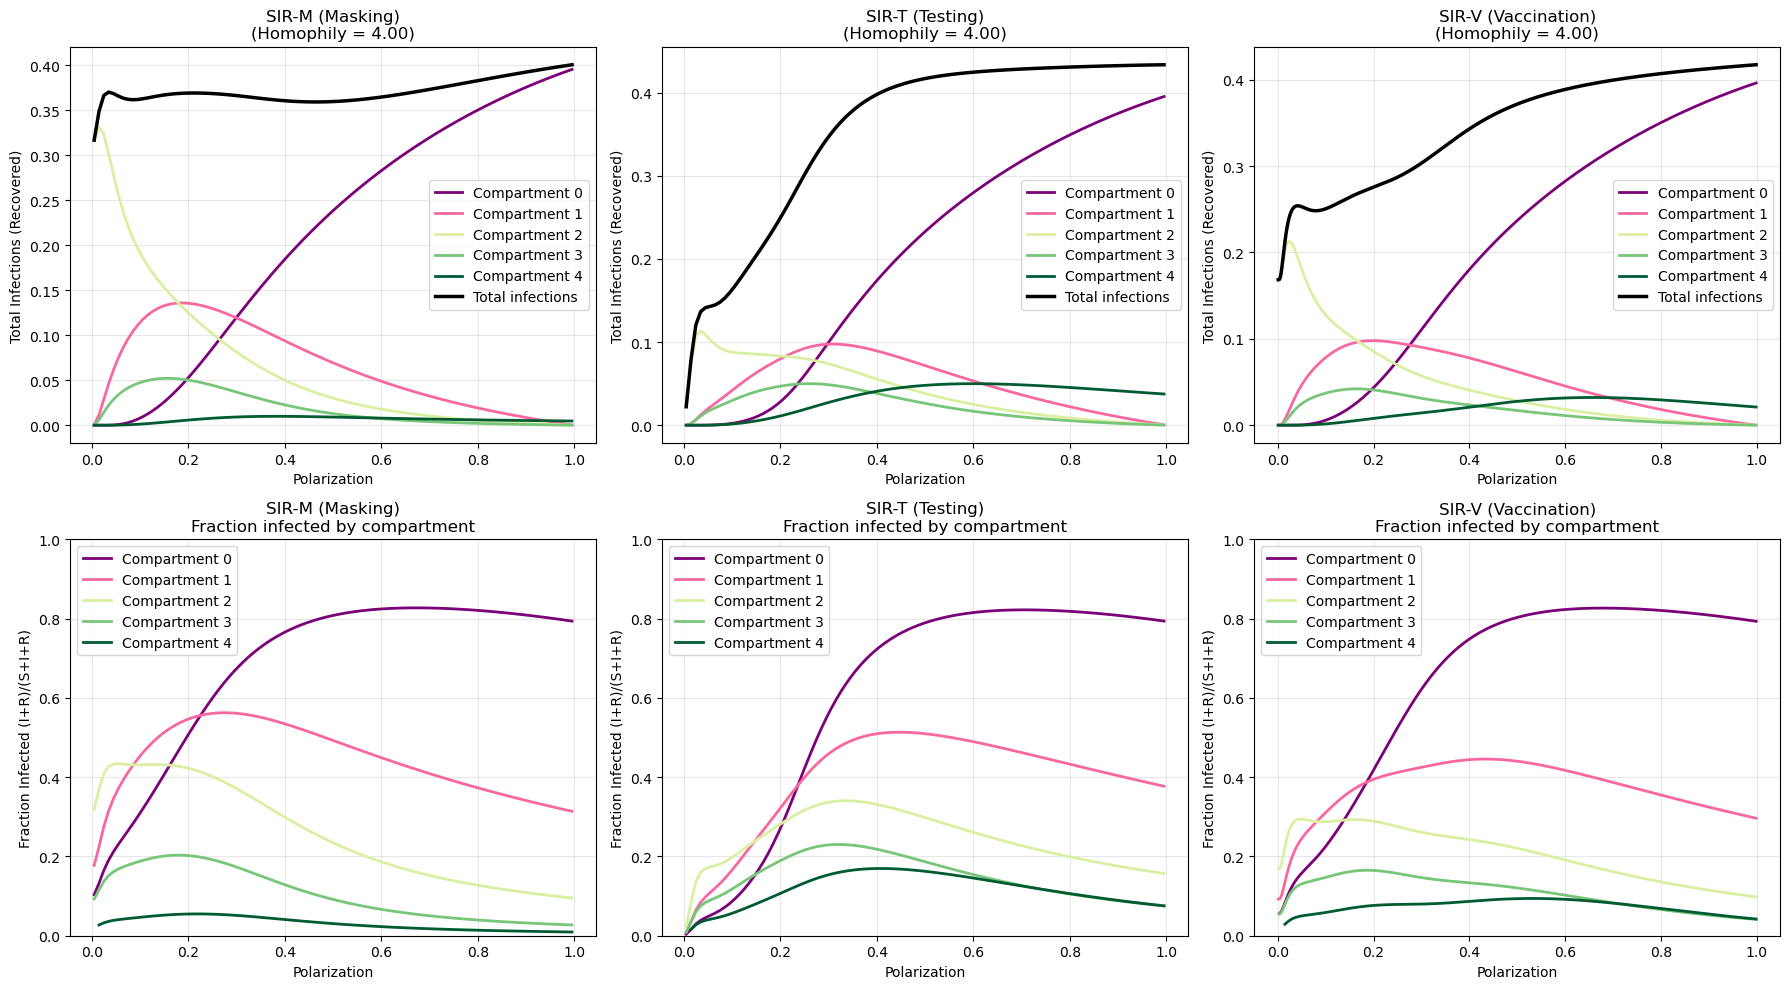

In [70]:
def plot_infections_by_polarization_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, hom_value=6.0):
    """
    Plot 3x2 grid:
    Top row: 3 infections by polarization plots (one per model)
    Bottom row: 3 fraction infected by compartment plots (one per model)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    # Top row: infections by polarization
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        hom_values = hom_grid[:, 0]
        hom_idx = np.argmin(np.abs(hom_values - hom_value))
        
        pol_values = pol_grid[hom_idx, :]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[hom_idx, :, :]
        
        for i in range(5):
            axs[0, col].plot(pol_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(pol_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Polarization')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Homophily = {hom_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: fraction infected by compartment
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        hom_values = hom_grid[:, 0]
        hom_idx = np.argmin(np.abs(hom_values - hom_value))
        
        pol_values = pol_grid[hom_idx, :]
        
        S_data = sweep_result["final_state"]["S"]
        I_data = sweep_result["final_state"]["I"]
        R_data = sweep_result["final_state"]["R"]
        
        S_slice = S_data[hom_idx, :, :]
        I_slice = I_data[hom_idx, :, :]
        R_slice = R_data[hom_idx, :, :]
        
        total_population = S_slice + I_slice + R_slice
        if col == 2:
            V_data = sweep_result["final_state"]["V"]
            V_slice = V_data[hom_idx, :, :]
            total_population += V_slice
        fraction_infected = (I_slice + R_slice) / total_population
        
        
        for i in range(5):
            axs[1, col].plot(pol_values, fraction_infected[:, i], 
                           label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[1, col].set_xlabel('Polarization')
        axs[1, col].set_ylabel('Fraction Infected (I+R)/(S+I+R)')
        axs[1, col].set_title(f'{model_name}\nFraction infected by compartment')
        axs[1, col].legend()
        axs[1, col].grid(True, alpha=0.3)
        axs[1, col].set_ylim([0, 1])
    
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_polarization_three_models(RM_1, RT_1, RV_1, hom_value=6.0)
plt.show()

fig = plot_infections_by_polarization_three_models(RM_1, RT_1, RV_1, hom_value=4.0)
plt.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1507510711.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  r_inf, = fsolve(func, 0.5)
C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1507510711.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  r_inf, = fsolve(func, 0.5)


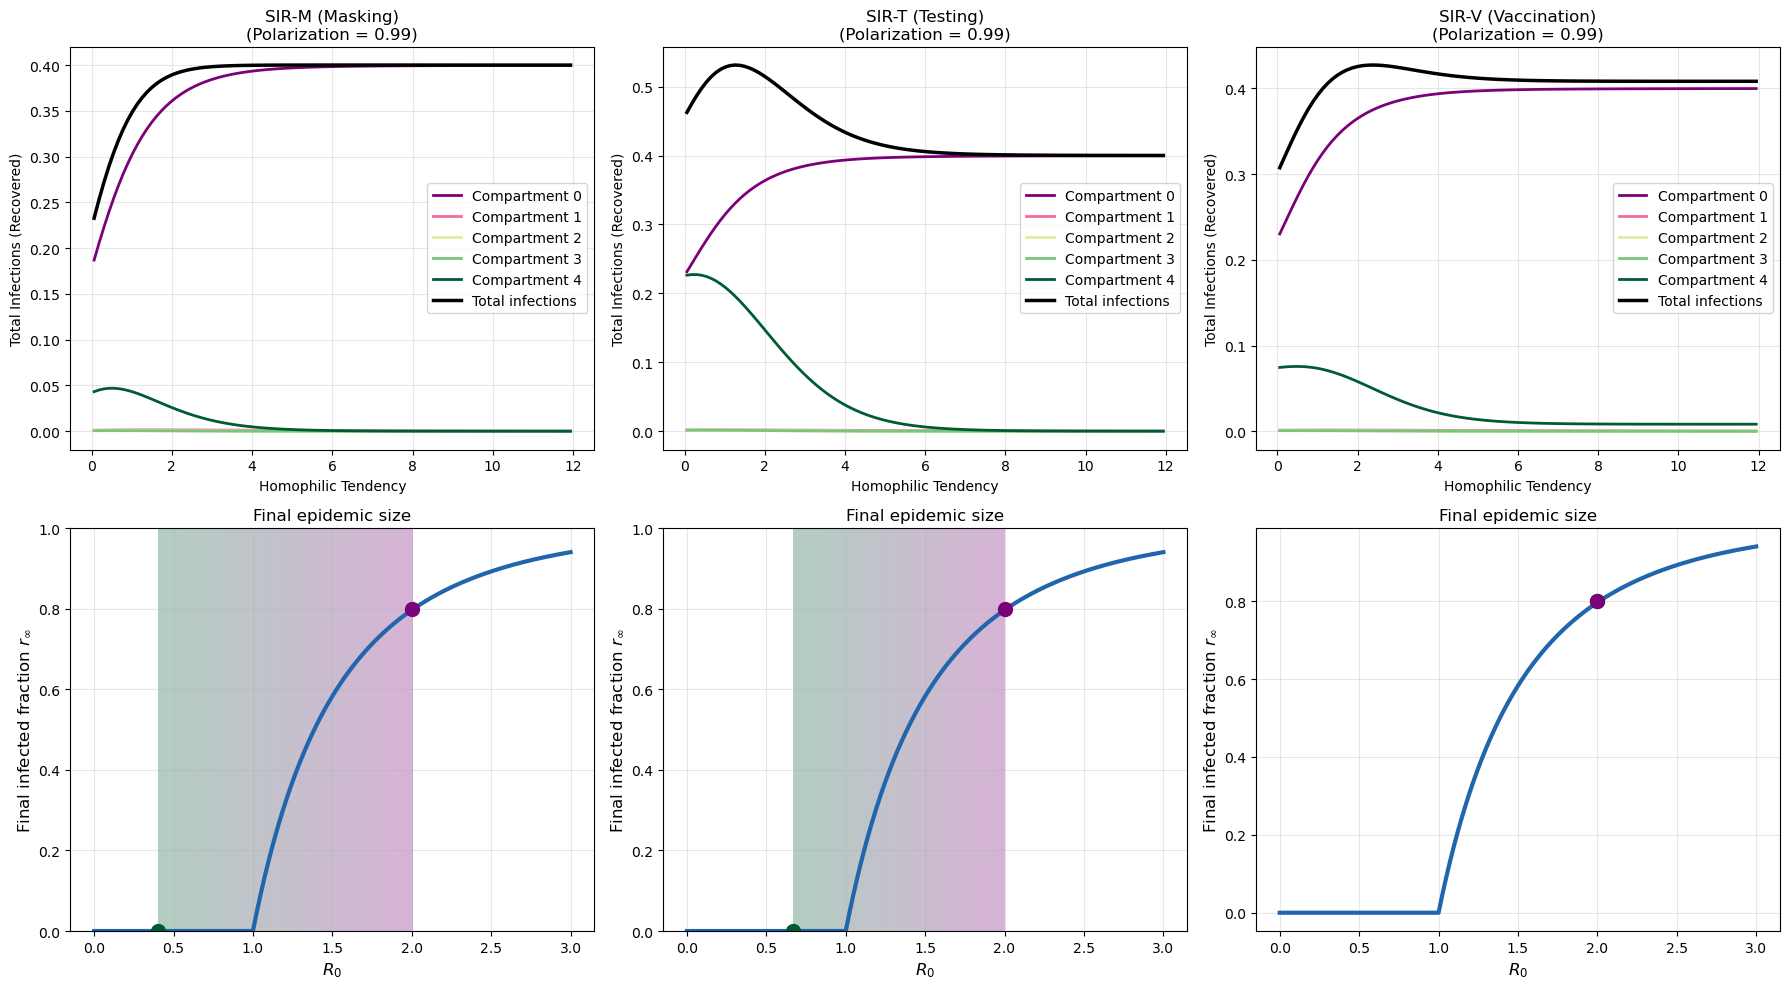

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Create a custom colormap from purple to yellow/green
colors_custom = ['#7a0177', '#c51b8a', '#f768a1', '#fbb4b9', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot 3x2 grid:
    Top row: 3 infections by homophily plots (one per model)
    Bottom row: 3 r_inf(R0) plots (one per model)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    # Top row: infections by homophily
    for col in range(3):
        sweep_result = sweep_results[col]
        model_name = model_names[col]
        
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        hom_values = hom_grid[:, pol_idx]
        
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        for i in range(5):
            axs[0, col].plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                           color=compartment_colors[i], linewidth=2)
        
        axs[0, col].plot(hom_values, np.sum(R_slice, 1), color="#000", 
                        label="Total infections", linewidth=2.5)
        
        axs[0, col].set_xlabel('Homophilic Tendency')
        axs[0, col].set_ylabel('Total Infections (Recovered)')
        axs[0, col].set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        axs[0, col].legend()
        axs[0, col].grid(True, alpha=0.3)
    
    # Bottom row: r_inf(R0) plots
    R0_values = np.linspace(0, 3, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    for col in range(3):
        axs[1, col].plot(R0_values, final_sizes, lw=3, color='#2166ac')
        axs[1, col].set_xlabel(r"$R_0$", fontsize=12)
        axs[1, col].set_ylabel(r"Final infected fraction $r_\infty$", fontsize=12)
        axs[1, col].set_title(f"Final epidemic size", fontsize=12)
        axs[1, col].grid(True, alpha=0.3)
    
    # Add gradient-filled rectangles for first two plots
    for col in range(2):
        # Green point coordinates
        green_R0 = 0.4 if col == 0 else 0.2/(0.1+0.2)
        
        # Purple point coordinates
        purple_R0 = 2
        purple_rinf = final_size(purple_R0)
        
        # Create gradient rectangle
        # Get axis limits
        y_max = 1
        y_min = 0
        
        # Create a gradient using imshow
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
        
        # Create custom colormap from green to purple
        cmap = mcolors.LinearSegmentedColormap.from_list(
            'green_purple', 
            [colors_custom[-1], colors_custom[0]]
        )
        
        axs[1, col].imshow(
            gradient,
            extent=[green_R0, purple_R0, y_min, y_max],
            aspect='auto',
            alpha=0.3,
            cmap=cmap,
            zorder=0
        )
    
    # Plot the marker points
    axs[1,0].plot(0.4, 0, 'o', markersize=10, color=colors_custom[-1])
    axs[1,0].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    axs[1,1].plot(0.2/(0.1+0.2), 0, 'o', markersize=10, color=colors_custom[-1])
    axs[1,1].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    axs[1,2].plot(2, 0.8, 'o', markersize=10, color=colors_custom[-1])
    axs[1,2].plot(2, 0.8, 'o', markersize=10, color=colors_custom[0])
    
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_homophily_three_models(RM_1, RT_1, RV_1, pol_value=0.99)
plt.show()

fig.savefig("figures/SI/explanation.pdf")

In [48]:
0.2/(0.1+0.198)

0.6711409395973154

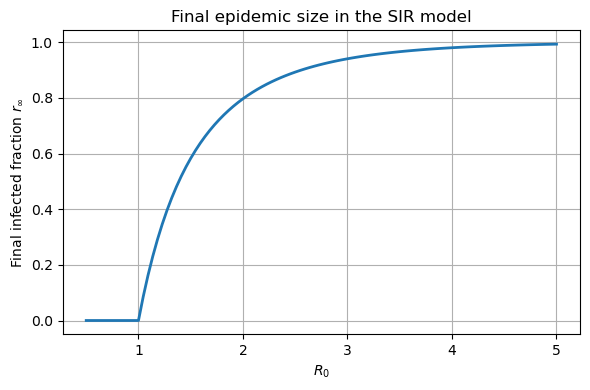

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)  # good initial guess
    return r_inf

# Range of R0 values
R0_values = np.linspace(0.5, 5, 100)
final_sizes = [final_size(R0) for R0 in R0_values]

# Plot
plt.figure(figsize=(6,4))
plt.plot(R0_values, final_sizes, lw=2)
plt.xlabel(r"$R_0$")
plt.ylabel("Final infected fraction $r_\\infty$")
plt.title("Final epidemic size in the SIR model")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1251015167.py:12: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  r_inf, = fsolve(func, 0.5)
C:\Users\nel_t\AppData\Local\Temp\ipykernel_14744\1251015167.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


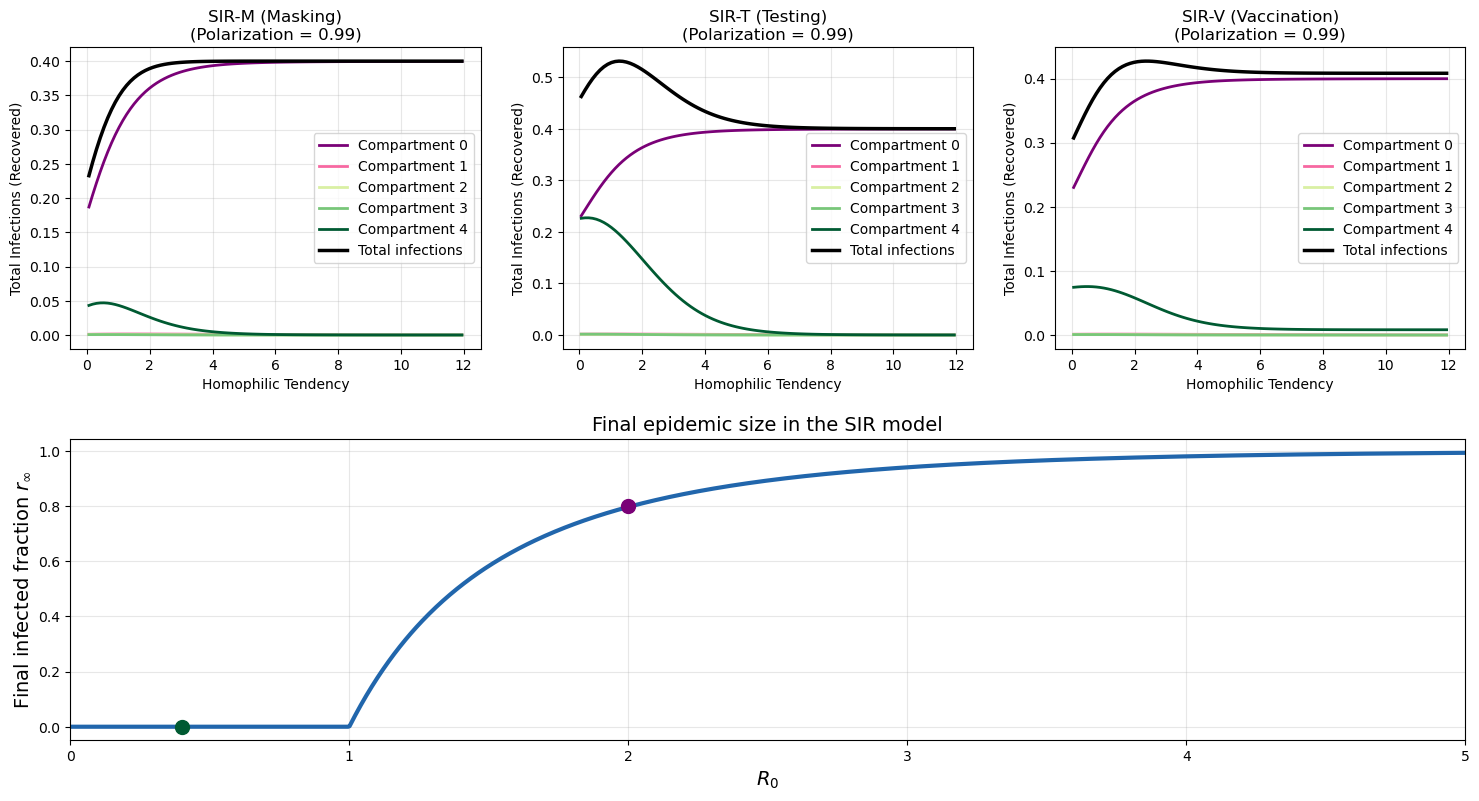

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.colors as mcolors

# Create a custom colormap from purple to yellow/green
colors_custom = ['#7a0177', '#c51b8a', '#f768a1', '#fbb4b9', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']

def final_size(R0):
    """Return final epidemic size r_inf for given R0."""
    func = lambda r: 1 - np.exp(-R0 * r) - r
    r_inf, = fsolve(func, 0.5)
    return r_inf

def plot_infections_by_homophily_three_models(sweep_SIRM, sweep_SIRT, sweep_SIRV, pol_value=0.5):
    """
    Plot total infections for each compartment across homophily values
    at a fixed polarization value for three models side by side,
    with final size curve below
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create figure with gridspec for custom layout
    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.3)
    
    # Top row: three model subplots
    axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
    
    # Bottom row: one wide subplot
    ax_bottom = fig.add_subplot(gs[1, :])
    
    sweep_results = [sweep_SIRM, sweep_SIRT, sweep_SIRV]
    model_names = ['SIR-M (Masking)', 'SIR-T (Testing)', 'SIR-V (Vaccination)']
    
    # Select 5 colors evenly spaced from the custom colormap
    color_indices = [0, 2, 4, 6, 9]
    compartment_colors = [colors_custom[i] for i in color_indices]
    
    for ax, sweep_result, model_name in zip(axes_top, sweep_results, model_names):
        # Get the parameter grids
        pol_grid = sweep_result["parameter_grid"]["param1_vals"]
        hom_grid = sweep_result["parameter_grid"]["param2_vals"]
        
        # Find the index closest to desired polarization
        pol_values = pol_grid[0, :]  
        pol_idx = np.argmin(np.abs(pol_values - pol_value))
        
        # Extract the slice: all homophily values, fixed polarization
        hom_values = hom_grid[:, pol_idx]
        
        # Get recovered (= total infected) for each compartment
        R_data = sweep_result["final_state"]["R"]
        R_slice = R_data[:, pol_idx, :]
        
        # Plot each compartment
        for i in range(5):
            ax.plot(hom_values, R_slice[:, i], label=f'Compartment {i}', 
                   color=compartment_colors[i], linewidth=2)
        
        # Plot total
        ax.plot(hom_values, np.sum(R_slice, 1), color="#000", 
               label="Total infections", linewidth=2.5)
        
        ax.set_xlabel('Homophilic Tendency')
        ax.set_ylabel('Total Infections (Recovered)')
        ax.set_title(f'{model_name}\n(Polarization = {pol_value:.2f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Bottom plot: Final size curve
    R0_values = np.linspace(0, 5, 1000)
    final_sizes = [final_size(R0) for R0 in R0_values]
    
    ax_bottom.plot(R0_values, final_sizes, lw=3, color='#2166ac')
    ax_bottom.set_xlabel(r"$R_0$", fontsize=14)
    ax_bottom.set_ylabel(r"Final infected fraction $r_\infty$", fontsize=14)
    ax_bottom.set_title("Final epidemic size in the SIR model", fontsize=14)
    ax_bottom.grid(True, alpha=0.3)
    ax_bottom.set_xlim([0,5])
    ax_bottom.plot(0.4,0,'o', markersize =10, color = '#005a32')
    ax_bottom.plot(2,  0.8,'o',markersize=10, color ='#7a0177')
    plt.tight_layout()
    return fig

# Use it
fig = plot_infections_by_homophily_three_models(RM_1, RT_1, RV_1, pol_value=0.99)
plt.show()

In [7]:
P_min_M, P_max_M = find_hpol_minmax(SIRM, mus, PARAMS)
P_min_T, P_max_T = find_hpol_minmax(SIRT, taus, PARAMS)
P_min_V, P_max_V = find_hpol_minmax(SIRV, xis, PARAMS)

Minimum R+I value: 0.0002
   at polarization = 0.2994, homophily = 3.1715
Maximum R+I value: 0.0002
   at polarization = 0.2506, homophily = 2.5085
Minimum R+I value: 0.4382
   at polarization = 0.4605, homophily = 2.0179
Maximum R+I value: 0.4602
   at polarization = 0.4995, homophily = 2.5061
Minimum R+I value: 0.2086
   at polarization = 0.5506, homophily = 1.6100
Maximum R+I value: 0.2386
   at polarization = 0.5994, homophily = 2.3900


Percentage increase in infections for M model: -55.24%


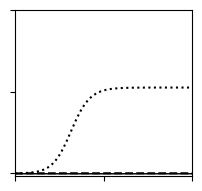

In [8]:
N_days = 1001
days = np.arange(0, N_days+1, 1)

MINS_M, MAXS_M, BASES_M, OG_M = calc_minmax_trajectories(SIRM, P_min_M, P_max_M, mus["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_M = plot_double_comparison(days, MINS_M, MAXS_M, BASES_M, OG_M, "figures/Fig_2/I(pol,hom)_M.pdf", Lx, Ly)

avg_predicted = (MINS_M[0][-1] + MINS_M[1][-1] + MAXS_M[0][-1] + MAXS_M[1][-1]) / 4

avg_base = (BASES_M[0][-1] + BASES_M[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base) * 100
print(f"Percentage increase in infections for M model: {perc_increase:.2f}%")

increase in infections for T model: x 680.78


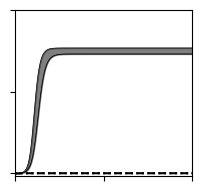

In [9]:
MINS_T, MAXS_T, BASES_T,OG_T = calc_minmax_trajectories(SIRT, P_min_T, P_max_T, taus["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_T = plot_double_comparison(days, MINS_T, MAXS_T, BASES_T, OG_T, "figures/Fig_2/I(pol,hom)_T.pdf", Lx, Ly)

avg_predicted = (MINS_T[0][-1] + MINS_T[1][-1] + MAXS_T[0][-1] + MAXS_T[1][-1]) / 4

avg_base = (BASES_T[0][-1] + BASES_T[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base)
print(f"increase in infections for T model: x {perc_increase:.2f}")

Percentage increase in infections for V model: 128.31%


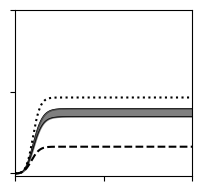

In [10]:
MINS_V, MAXS_V, BASES_V, OG_V = calc_minmax_trajectories(SIRV, P_min_V, P_max_V, xis["mean"][1], PARAMS, simulated_days = N_days)
fig_comparison_V = plot_double_comparison(days, MINS_V, MAXS_V, BASES_V, OG_V, "figures/Fig_2/I(pol,hom)_V.pdf", Lx, Ly)

avg_predicted = (MINS_V[0][-1] + MINS_V[1][-1] + MAXS_V[0][-1] + MAXS_V[1][-1]) / 4

avg_base = (BASES_V[0][-1] + BASES_V[1][-1]) / 2

perc_increase = ((avg_predicted - avg_base) / avg_base) * 100
print(f"Percentage increase in infections for V model: {perc_increase:.2f}%")

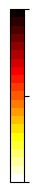

In [15]:
cbar_fig = create_standalone_colorbar(
    cmap_name=my_map,
    vmin=0,
    vmax=1,
    height=Ly,
    width=Ly/3,
    ticks=[0, 0.5, 1],
    ticklabels=[],
    save_path='figures/Fig_1/colorbar_Inf.pdf'
)

In [12]:
betas = [0.3]
PS = 21
i = 0

min_POL_M = np.zeros(len(betas))
max_POL_M = np.zeros(len(betas))

min_HOM_M = np.zeros(len(betas))
max_HOM_M = np.zeros(len(betas))

NP = 100
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 20, "n": NH}

print(beta)
PARAMS["beta_M"] = beta
PARAMS["dT"] = 0.1
RM_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=2500
)
TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
TI = np.sum(TI, axis=2)
max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
max_POL_M[i] = max_pol
max_HOM_M[i] = max_homophily


min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
min_POL_M[i] = min_pol
min_HOM_M[i] = min_homophily
i += 1

0.3


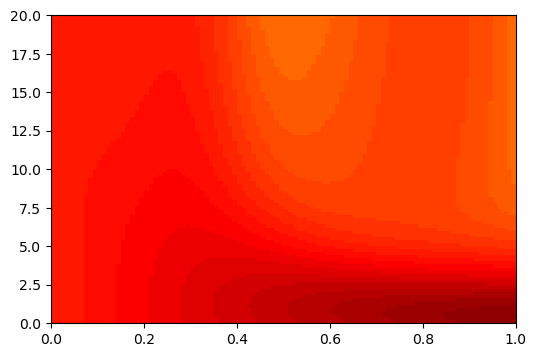

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
TI = np.sum(TI, axis=2)
ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 20],
    aspect='auto')


In [14]:
beta = 0.3
PS = 51
i = 0

min_POL_M = np.zeros(len(betas))
max_POL_M = np.zeros(len(betas))

min_HOM_M = np.zeros(len(betas))
max_HOM_M = np.zeros(len(betas))

NP = 100
NH = 100
pol_range = {"m": 0, "M": 1, "n": NP}
homophilic_tendency = {"m": 0, "M": 20, "n": NH}

print(beta)
PARAMS["beta_M"] = beta
PARAMS["dT"] = 0.1
RM_1_L = sweep_two_parameters(
    model_module=SIRT,
    param1_name="beta_params",           # parameter 1 name
    param1_range=pol_range,    # parameter 1 range
    param2_name="homophilic_tendency",      # parameter 2 name
    param2_range=homophilic_tendency,         # parameter 2 range
    custom_base_params=PARAMS,
    simulated_days=1000,
    population_size=PS,
    batch_size=2500
)
TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
TI = np.sum(TI, axis=2)
max_idx = np.unravel_index(np.nanargmax(TI, axis=None), TI.shape)
max_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (max_idx[1] / (pol_range["n"] - 1))
max_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (max_idx[0] / (homophilic_tendency["n"] - 1))
max_POL_M[i] = max_pol
max_HOM_M[i] = max_homophily


min_idx = np.unravel_index(np.nanargmin(TI + np.eye(*TI.shape) * np.nanmax(TI), axis=None), TI.shape)
min_pol = pol_range["m"] + (pol_range["M"] - pol_range["m"]) * (min_idx[1] / (pol_range["n"] - 1))
min_homophily = homophilic_tendency["m"] + (homophilic_tendency["M"] - homophilic_tendency["m"]) * (min_idx[0] / (homophilic_tendency["n"] - 1))
min_POL_M[i] = min_pol
min_HOM_M[i] = min_homophily
i += 1

0.3


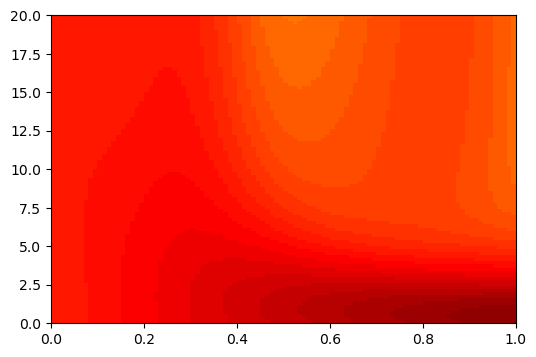

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
TI = RM_1_L["final_state"]["I"] + RM_1_L["final_state"]["R"]
TI = np.sum(TI, axis=2)
ax.imshow(
    TI, vmin = 0, vmax = 1, cmap = my_map,
    origin='lower', extent=[0, 1, 0, 20],
    aspect='auto')
